## 1. Environment Setup <a name='setup'></a>

In [1]:
import os

BASE_DIR = '/content/press_start'
DATA_DIR = os.path.join(BASE_DIR, 'data')
CLEAN_DIR = os.path.join(BASE_DIR, 'clean')
PLOT_DIR = os.path.join(BASE_DIR, 'plots')

for d in [DATA_DIR, CLEAN_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready ✓")

Directories ready ✓


In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost statsmodels -q
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
%matplotlib inline

RANDOM_STATE = 42
TEST_SIZE    = 0.2
TARGET_COL   = 'Estimated_Owners'
COLORS       = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# FEATURE_COLS = ['Price_Real', 'Genre', 'Is_Holiday', 'Positive_Ratio',
#                 'DLC_Count', 'Release_Month']

FEATURE_COLS = ['Price_Real', 'Is_Holiday', 'Positive_Ratio',
                'DLC_Count', 'Release_Month']

CPI_DEFLATORS = {
    1998: 0.648, 1999: 0.661, 2000: 0.681, 2001: 0.699,
    2002: 0.710, 2003: 0.724, 2004: 0.743, 2005: 0.767,
    2006: 0.791, 2007: 0.814, 2008: 0.845, 2009: 0.841,
    2010: 0.856, 2011: 0.884, 2012: 0.904, 2013: 0.919,
    2014: 0.933, 2015: 0.934, 2016: 0.947, 2017: 0.966,
    2018: 0.989, 2019: 1.007, 2020: 1.000, 2021: 1.047,
    2022: 1.128, 2023: 1.196, 2024: 1.231, 2025: 1.258,
}

def adjust_price_cpi(price, year):
    deflator = CPI_DEFLATORS.get(int(year), 1.0)
    return price / deflator

print("Libraries loaded ✓")
print(f"XGBoost version: {xgb.__version__} ✓")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries loaded ✓
XGBoost version: 3.2.0 ✓


## 2. Problem Statement <a name='problem'></a>

The video game industry has seen consistent price increases, with AAA titles now regularly launching at USD $70. Yet publishers and developers lack a data-driven framework for determining whether these prices maximise sales or actively suppress them.

**Central Question:** Given a game's features - including its price - can we predict how many copies it will sell, and use that model to find the price point that maximises sales?

**Sub-questions:**
- How strongly does price correlate with sales volume?
- Do holiday/seasonal releases sell significantly more copies?
- What is the optimal price point predicted by each model?
- Are games currently priced above or below that optimum - i.e., are they overpriced?

**Problem Type:** Regression - predicting a continuous numerical value (estimated owner count).

### Stakeholders

| Stakeholder | Need |
|-------------|------|
| Game publishers | Set a price that maximises revenue without suppressing sales |
| Independent developers | Understand how pricing decisions affect their market reach |
| Consumers | Understand whether current pricing reflects market demand |

### Why it Matters
A data-driven pricing model could save publishers from leaving money on the table through under-pricing, or losing customers through over-pricing. For indie developers, this insight is particularly valuable as pricing is one of the few levers fully within their control.


## 3. Dataset Download <a name='download'></a>

### Datasets Used

All three datasets are sourced from Kaggle and focus on the Steam platform, which provides the richest publicly available combination of **price**, **sales proxy (estimated owners)**, **genre**, **review scores**, and **release dates**.

| # | Kaggle Slug | Description | Key Columns |
|---|-------------|-------------|-------------|
| 1 | `nikdavis/steam-store-games` | ~27,000 Steam games scraped 2019. Clean, well-structured. | `price`, `owners` (range), `release_date`, `genres`, `positive_ratings`, `negative_ratings` |
| 2 | `fronkongames/steam-games-dataset` | 110,000+ Steam games, most comprehensive available. | `price`, `estimated_owners` (range), `release_date`, `genres`, `positive`, `negative`, `peak_ccu` |
| 3 | `artermiloff/steam-games-dataset` | 100,000+ Steam games as of March 2025. Most up-to-date dataset covering the modern $70 pricing era. | `price`, `estimated_owners` (range), `release_date`, `genres`, `positive`, `negative`, `metacritic_score`, `dlc_count`, `peak_ccu`, `discount` |

**Why Steam?**  
Unlike the classic vgsales datasets, Steam data includes **price** as a first-class feature — essential for the price optimisation analysis. The owner range (e.g. "20000 - 50000") serves as our sales proxy; we take the midpoint as the target value. Steam also provides release dates at the month level, enabling seasonality analysis.

---
### Kaggle Credentials
To download the datasets you need a Kaggle account and API token.  
1. Go to **kaggle.com → Settings → API Tokens → Generate New Token**
2. Copy your username and key into the cell below


In [3]:
import os

# ── Fill in your own Kaggle credentials ──────────────────────────────────────
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'   # e.g. 'matthew_singh'
os.environ['KAGGLE_KEY']      = 'YOUR_KAGGLE_KEY'        # the key string from your token
# ─────────────────────────────────────────────────────────────────────────────

!pip install kaggle -q
print("Kaggle configured ✓")


Kaggle configured ✓



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
datasets_to_download = {
    'dataset1': 'nikdavis/steam-store-games',
    'dataset2': 'fronkongames/steam-games-dataset',
    'dataset3': 'artermiloff/steam-games-dataset',
}

for key, slug in datasets_to_download.items():
    out = os.path.join(DATA_DIR, key)
    os.makedirs(out, exist_ok=True)
    print(f"Downloading {slug} ...")
    !kaggle datasets download -d {slug} -p {out} --unzip -q
    print(f"  → {os.listdir(out)}\n")

print("All downloads complete ✓")


Dataset URL: https://www.kaggle.com/datasets/nikdavis/steam-store-games
License(s): Attribution 4.0 International (CC BY 4.0)
  → ['steam.csv', 'steamspy_tag_data.csv', 'steam_description_data.csv', 'steam_media_data.csv', 'steam_requirements_data.csv', 'steam_support_info.csv']

Dataset URL: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset
License(s): MIT
  → ['games.csv', 'games.json']

Dataset URL: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset
License(s): MIT
  → ['games_march2025_cleaned.csv', 'games_march2025_full.csv', 'games_may2024_cleaned.csv', 'games_may2024_full.csv', 'steam_games.csv']

All downloads complete ✓


## 4. Data Inspection <a name='inspect'></a>

We inspect the raw files before any cleaning to understand column names, data types, and missing value patterns. **Update the paths below** after running the download cell - check what CSV files were created.


In [5]:
# ── Update filenames if needed based on download output above ─────────────────
RAW_PATH_1 = os.path.join(DATA_DIR, 'dataset1', 'steam.csv')
RAW_PATH_2 = os.path.join(DATA_DIR, 'dataset2', 'games.csv')
RAW_PATH_3 = os.path.join(DATA_DIR, 'dataset3', 'games_march2025_cleaned.csv')

raw_paths = {
    'Dataset 1 (nikdavis)':      RAW_PATH_1,
    'Dataset 2 (fronkongames)':  RAW_PATH_2,
    'Dataset 3 (artermiloff)':   RAW_PATH_3,
}

raw_dfs = {}
for name, path in raw_paths.items():
    try:
        df = pd.read_csv(path)
        raw_dfs[name] = df
        print(f"\n{'='*60}")
        print(f"{name} |  Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        display(df.head(3))
        print("\nMissing values (columns with nulls only):")
        m = df.isnull().sum()
        print(m[m > 0].to_string() if m.any() else "  None")
    except FileNotFoundError:
        print(f"\n[!] Not found: {path} — check filename above")



Dataset 1 (nikdavis) |  Shape: (27075, 18)
Columns: ['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price']


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99



Missing values (columns with nulls only):
developer     1
publisher    14

Dataset 2 (fronkongames) |  Shape: (122611, 39)
Columns: ['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN



Missing values (columns with nulls only):
AppID                  1
About the game      8449
Reviews           110541
Header image          81
Website            72935
Support url        68469
Support email      22263
Metacritic url    118355
Score rank        122571
Notes             100153
Developers          8437
Publishers          8909
Categories          8953
Genres              8413
Tags               39265
Screenshots         6018
Movies            122611

Dataset 3 (artermiloff) |  Shape: (89618, 47)
Columns: ['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank'

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366



Missing values (columns with nulls only):
detailed_description      197
about_the_game            220
short_description         120
reviews                 79217
website                 48504
support_url             45508
support_email           10820
metacritic_url          86071
notes                   72975
score_rank              89579


## 5. Preprocessing <a name='preprocessing'></a>

Each dataset has different column names and structures. We standardise them around these core features:

| Column | Source | Notes |
|--------|--------|-------|
| `Price` | Direct from dataset | USD, 0 = free-to-play |
| `Estimated_Owners` | Parsed from range string | Midpoint of range e.g. "20000 - 50000" → 35000 |
| `Genre` | Label-encoded | Categorical |
| `Release_Month` | Parsed from release date | 1-12 |
| `Is_Holiday` | Engineered | 1 if release month is Oct, Nov, or Dec |
| `Positive_Ratio` | Computed | positive / (positive + negative) ratings |
| `DLC_Count` | Direct | Number of DLCs |

### Why these features?
- **Price** is the central feature for the optimisation analysis
- **Is_Holiday** addresses the TA's seasonality comment directly
- **Positive_Ratio** captures game quality - a confound we must control for
- **DLC_Count** reflects franchise depth and post-launch investment


In [6]:
def parse_owners(owners_str):
    """
    Convert owner range string to numeric midpoint.
    e.g. '20000 - 50000' → 35000
         '0 - 20000'     → 10000
    Returns NaN if unparseable.
    """
    try:
        owners_str = str(owners_str).replace(',', '').strip()
        if '-' in owners_str:
            parts = owners_str.split('-')
            lo, hi = float(parts[0].strip()), float(parts[1].strip())
            return (lo + hi) / 2
        return float(owners_str)
    except:
        return np.nan


# ── FIXED parse_release_month (Matthew T4) ───────────────────────────────────
# Root cause: pd.to_datetime(..., infer_datetime_format=True) was deprecated
# in pandas >= 2.0 and silently failed on formats like 'Nov 2020', returning
# NaT → NaN month → Is_Holiday always 0.
# Fix: explicit format list covers all formats found in our datasets.

EXPLICIT_DATE_FORMATS = [
    '%Y-%m-%d',     # 2020-11-02  ← Dataset 3 (artermiloff) uses this
    '%b %Y',        # Nov 2020
    '%B %Y',        # November 2020
    '%b %d, %Y',    # Nov 2, 2020
    '%B %d, %Y',    # November 2, 2020
    '%d %b, %Y',    # 2 Nov, 2020
    '%d %B, %Y',    # 2 November, 2020
    '%Y',           # 2020 (year only)
]

def parse_release_month(date_str):
    """Extract month (1-12) from various date string formats — pandas 2.x safe."""
    if pd.isna(date_str):
        return np.nan
    date_str = str(date_str).strip()
    for fmt in EXPLICIT_DATE_FORMATS:
        try:
            return pd.to_datetime(date_str, format=fmt).month
        except (ValueError, TypeError):
            continue
    try:
        return pd.to_datetime(date_str).month
    except:
        return np.nan


def encode_col(df, col):
    le = LabelEncoder()
    df[col] = df[col].fillna('Unknown').astype(str)
    df[col] = le.fit_transform(df[col])
    return df

def clip_and_log(df, col, upper_q=0.99):
    cap = df[col].quantile(upper_q)
    n   = (df[col] > cap).sum()
    df[col + '_raw'] = df[col]
    df[col] = df[col].clip(upper=cap)
    df[col] = np.log1p(df[col])
    print(f"  Clipped {n} outlier(s) at {cap:,.0f} owners, applied log1p")
    return df


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET 1 — nikdavis/steam-store-games
# ══════════════════════════════════════════════════════════════════════════════
def clean_dataset1(path):
    print("\nCleaning Dataset 1 (nikdavis)...")
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    rename = {
        'price':            'Price',
        'owners':           'Estimated_Owners',
        'genres':           'Genre',
        'release_date':     'Release_Date',
        'positive_ratings': 'Positive',
        'negative_ratings': 'Negative',
        'developer':        'Developer',
        'publisher':        'Publisher',
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    df['Estimated_Owners'] = df['Estimated_Owners'].apply(parse_owners)
    df = df.dropna(subset=['Estimated_Owners', 'Price'])
    df = df[df['Price'] >= 0]

    before = len(df)
    df = df[df['Estimated_Owners'] > 0]
    print(f"  Dropped {before - len(df)} rows with 0 owners")

    df['Release_Date']  = pd.to_datetime(df['Release_Date'], errors='coerce')
    df['Release_Month'] = df['Release_Date'].apply(parse_release_month)
    df['Release_Month'] = df['Release_Month'].fillna(6).astype(int)
    df['Is_Holiday']    = df['Release_Month'].apply(
        lambda m: 1 if m in [10, 11, 12] else 0)
    print(f"  Is_Holiday — mean: {df['Is_Holiday'].mean():.3f}  "
          f"(holiday releases: {df['Is_Holiday'].sum()} / {len(df)})")

    total = df['Positive'].fillna(0) + df['Negative'].fillna(0)
    df['Positive_Ratio'] = np.where(total > 0, df['Positive'].fillna(0) / total, 0.5)
    df['DLC_Count'] = 0

    df = encode_col(df, 'Genre')
    df = clip_and_log(df, 'Estimated_Owners')
    
    before = len(df)
    df = df[df['Estimated_Owners_raw'] > 20000]
    print(f"  Dropped {before - len(df)} rows in lowest owner bucket (≤20,000)")

    df['Release_Year'] = df['Release_Date'].dt.year.fillna(2015).astype(int)
    df['Price_Real'] = df.apply(
        lambda row: adjust_price_cpi(row['Price'], row['Release_Year']), axis=1
    )
    print(f"  Price CPI-adjusted to 2020 dollars ✓")
    print(f"  Release_Year range: {df['Release_Year'].min()} – {df['Release_Year'].max()}")

    print(f"  Final shape: {df.shape}")
    return df

In [8]:
def clean_dataset2(path):
    print("\nCleaning Dataset 2 (fronkongames)...")
    raw = pd.read_csv(path)
    raw.columns = [c.strip() for c in raw.columns]

    # CSV index consumed AppID — all columns are shifted 1 left.
    df = pd.DataFrame()
    df['Release_Date']     = raw['Name']
    df['Estimated_Owners'] = raw['Release date'].apply(parse_owners)
    df['Price']            = pd.to_numeric(raw['Required age'],    errors='coerce')
    df['DLC_Count']        = pd.to_numeric(raw['Price'],           errors='coerce').fillna(0)
    df['Positive']         = pd.to_numeric(raw['Positive'], errors='coerce').fillna(0)
    df['Negative']         = pd.to_numeric(raw['Negative'], errors='coerce').fillna(0)
    df['Genre']            = raw['Categories']
    df['Peak_CCU']         = pd.to_numeric(raw['Estimated owners'],errors='coerce').fillna(0)

    df = df.dropna(subset=['Estimated_Owners', 'Price'])
    df = df[df['Price'] >= 0]

    before = len(df)
    df = df[df['Estimated_Owners'] > 0]
    print(f"  Dropped {before - len(df)} rows with 0 owners")

    df['Release_Month'] = df['Release_Date'].apply(parse_release_month)
    df['Release_Month'] = df['Release_Month'].fillna(6).astype(int)
    df['Is_Holiday']    = df['Release_Month'].isin([10, 11, 12]).astype(int)
    print(f"  Is_Holiday — mean: {df['Is_Holiday'].mean():.3f}  "
          f"(holiday releases: {df['Is_Holiday'].sum()} / {len(df)})")

    total = df['Positive'] + df['Negative']
    df['Positive_Ratio'] = np.where(total > 0, df['Positive'] / total, 0.5)

    df = encode_col(df, 'Genre')
    df = clip_and_log(df, 'Estimated_Owners')

    before = len(df)
    df = df[df['Estimated_Owners_raw'] > 20000]
    print(f"  Dropped {before - len(df)} rows in lowest owner bucket (≤20,000)")

    df['Release_Date_parsed'] = pd.to_datetime(df['Release_Date'], errors='coerce')
    df['Release_Year'] = df['Release_Date_parsed'].dt.year.fillna(2015).astype(int)
    df['Price_Real'] = df.apply(
        lambda row: adjust_price_cpi(row['Price'], row['Release_Year']), axis=1
    )
    print(f"  Price CPI-adjusted to 2020 dollars ✓")
    print(f"  Release_Year range: {df['Release_Year'].min()} – {df['Release_Year'].max()}")

    print(f"  Final shape: {df.shape}")
    return df

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET 3 — artermiloff/steam-games-dataset (March 2025)
# File: games_march2025_cleaned.csv
# This dataset has real SteamSpy owner ranges — no proxy needed.
# Key columns: price, estimated_owners (range), release_date (ISO),
#              genres (list string), positive, negative, metacritic_score,
#              dlc_count, peak_ccu, discount
# ══════════════════════════════════════════════════════════════════════════════
def clean_dataset3(path):
    print("\nCleaning Dataset 3 (artermiloff — March 2025)...")
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    rename = {
        'price':             'Price',
        'estimated_owners':  'Estimated_Owners',
        'genres':            'Genre',
        'release_date':      'Release_Date',
        'positive':          'Positive',
        'negative':          'Negative',
        'dlc_count':         'DLC_Count',
        'peak_ccu':          'Peak_CCU',
        'metacritic_score':  'Metacritic_Score',
        'discount':          'Discount',
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df = df.dropna(subset=['Price'])
    df = df[df['Price'] >= 0]

    df['Estimated_Owners'] = df['Estimated_Owners'].apply(parse_owners)
    df = df.dropna(subset=['Estimated_Owners'])
    before = len(df)
    df = df[df['Estimated_Owners'] > 0]
    print(f"  Dropped {before - len(df)} rows with 0 owners")

    df['Release_Month'] = df['Release_Date'].apply(parse_release_month)
    df['Release_Month'] = df['Release_Month'].fillna(6).astype(int)
    df['Is_Holiday']    = df['Release_Month'].isin([10, 11, 12]).astype(int)
    print(f"  Is_Holiday — mean: {df['Is_Holiday'].mean():.3f}  "
          f"(holiday releases: {df['Is_Holiday'].sum()} / {len(df)})")

    def extract_first_genre(genre_str):
        try:
            import ast
            genres = ast.literal_eval(str(genre_str))
            return genres[0] if genres else 'Unknown'
        except:
            return str(genre_str).strip("[]\\'\"`")

    df['Genre'] = df['Genre'].apply(extract_first_genre)

    total = df['Positive'].fillna(0) + df['Negative'].fillna(0)
    df['Positive_Ratio'] = np.where(total > 0, df['Positive'].fillna(0) / total, 0.5)

    if 'DLC_Count' not in df.columns:
        df['DLC_Count'] = 0

    df = encode_col(df, 'Genre')
    df = clip_and_log(df, 'Estimated_Owners')
    
    before = len(df)
    df = df[df['Estimated_Owners_raw'] > 20000]
    print(f"  Dropped {before - len(df)} rows in lowest owner bucket (≤20,000)")

    df['Release_Date_parsed'] = pd.to_datetime(df['Release_Date'], errors='coerce')
    df['Release_Year'] = df['Release_Date_parsed'].dt.year.fillna(2015).astype(int)
    df['Price_Real'] = df.apply(
        lambda row: adjust_price_cpi(row['Price'], row['Release_Year']), axis=1
    )
    print(f"  Price CPI-adjusted to 2020 dollars ✓")
    print(f"  Release_Year range: {df['Release_Year'].min()} – {df['Release_Year'].max()}")

    print(f"  Final shape: {df.shape}")
    return df

In [10]:
df1 = clean_dataset1(RAW_PATH_1)
df2 = clean_dataset2(RAW_PATH_2)
df3 = clean_dataset3(RAW_PATH_3)

datasets = {
    'Dataset 1 (nikdavis)':      df1,
    'Dataset 2 (fronkongames)':  df2,
    'Dataset 3 (artermiloff)':   df3,
}

# Save cleaned CSVs
df1.to_csv(os.path.join(CLEAN_DIR, 'dataset1_clean.csv'), index=False)
df2.to_csv(os.path.join(CLEAN_DIR, 'dataset2_clean.csv'), index=False)
df3.to_csv(os.path.join(CLEAN_DIR, 'dataset3_clean.csv'), index=False)
print("\nCleaned datasets saved ✓")



Cleaning Dataset 1 (nikdavis)...
  Dropped 0 rows with 0 owners
  Is_Holiday — mean: 0.260  (holiday releases: 7040 / 27075)
  Clipped 266 outlier(s) at 1,500,000 owners, applied log1p
  Dropped 18596 rows in lowest owner bucket (≤20,000)
  Price CPI-adjusted to 2020 dollars ✓
  Release_Year range: 1997 – 2019
  Final shape: (8479, 25)

Cleaning Dataset 2 (fronkongames)...
  Dropped 21641 rows with 0 owners
  Is_Holiday — mean: 0.272  (holiday releases: 27461 / 100970)
  Clipped 625 outlier(s) at 1,500,000 owners, applied log1p
  Dropped 75404 rows in lowest owner bucket (≤20,000)
  Price CPI-adjusted to 2020 dollars ✓
  Release_Year range: 1997 – 2025
  Final shape: (25566, 15)

Cleaning Dataset 3 (artermiloff — March 2025)...
  Dropped 8418 rows with 0 owners
  Is_Holiday — mean: 0.274  (holiday releases: 22226 / 81200)
  Clipped 559 outlier(s) at 1,500,000 owners, applied log1p
  Dropped 59320 rows in lowest owner bucket (≤20,000)
  Price CPI-adjusted to 2020 dollars ✓
  Release_Ye

#### Cross-Dataset split

In [11]:
def get_X_y_cross(train_datasets, test_dataset):
    train_df = pd.concat(train_datasets, ignore_index=True)
    X_train  = train_df[FEATURE_COLS]
    y_train  = train_df[TARGET_COL]
    X_test   = test_dataset[FEATURE_COLS]
    y_test   = test_dataset[TARGET_COL]
    return X_train, X_test, y_train, y_test

train_datasets = [
    datasets['Dataset 1 (nikdavis)'],
    datasets['Dataset 2 (fronkongames)']
]
test_dataset = datasets['Dataset 3 (artermiloff)']

X_train, X_test, y_train, y_test = get_X_y_cross(train_datasets, test_dataset)

print(f"Training size : {len(X_train):,} games (D1 + D2)")
print(f"Test size     : {len(X_test):,} games (D3 — March 2025)")
print(f"Year range (D1): {datasets['Dataset 1 (nikdavis)']['Release_Year'].min()} – {datasets['Dataset 1 (nikdavis)']['Release_Year'].max()}")
print(f"Year range (D2): {datasets['Dataset 2 (fronkongames)']['Release_Year'].min()} – {datasets['Dataset 2 (fronkongames)']['Release_Year'].max()}")
print(f"Year range (D3): {datasets['Dataset 3 (artermiloff)']['Release_Year'].min()} – {datasets['Dataset 3 (artermiloff)']['Release_Year'].max()}")

Training size : 34,045 games (D1 + D2)
Test size     : 21,880 games (D3 — March 2025)
Year range (D1): 1997 – 2019
Year range (D2): 1997 – 2025
Year range (D3): 1997 – 2025


#### Temporal Sanity Check

In [12]:
combined   = pd.concat(train_datasets, ignore_index=True)
train_mask = combined['Release_Year'] <= 2019

feats      = [c for c in FEATURE_COLS if c in combined.columns]
X_combined = combined[feats].select_dtypes(include=[np.number]).fillna(combined[feats].median())
y_combined = combined[TARGET_COL]

X_tr_temp = X_combined[train_mask];  y_tr_temp = y_combined[train_mask]
X_te_temp = X_combined[~train_mask]; y_te_temp = y_combined[~train_mask]

print(f"Temporal sanity check:")
print(f"  Train (pre-2020) : {train_mask.sum():,} games")
print(f"  Test  (2020+)    : {(~train_mask).sum():,} games")

Temporal sanity check:
  Train (pre-2020) : 21,076 games
  Test  (2020+)    : 12,969 games


## 6.1 Summary Statistics

In [13]:
for name, df in datasets.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    display(df[FEATURE_COLS + [TARGET_COL]].describe().round(3))


Dataset 1 (nikdavis)


,Price_Real,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,8479.000,8479.000,8479.000,8479.0,8479.00,8479.000
mean,7.592,0.245,0.731,0.0,6.52,11.630
std,8.660,0.430,0.177,0.0,3.35,1.178
min,0.000,0.000,0.000,0.0,1.00,10.463
25%,0.847,0.000,0.627,0.0,4.00,10.463
50%,5.166,0.000,0.768,0.0,7.00,11.225
75%,11.051,0.000,0.872,0.0,9.00,12.766
max,84.662,1.000,1.000,0.0,12.00,14.221



Dataset 2 (fronkongames)


,Price_Real,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,25566.000,25566.000,25566.000,25566.000,25566.000,25566.000
mean,4.535,0.259,0.769,31.187,6.608,11.414
std,6.324,0.438,0.188,34.102,3.400,1.126
min,0.000,0.000,0.000,0.000,1.000,10.463
25%,0.828,0.000,0.673,0.000,4.000,10.463
50%,2.629,0.000,0.811,20.000,7.000,11.225
75%,5.948,1.000,0.908,65.000,10.000,11.918
max,202.214,1.000,1.000,100.000,12.000,14.221



Dataset 3 (artermiloff)


,Price_Real,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,21880.000,21880.000,21880.000,21880.000,21880.000,21880.000
mean,8.942,0.265,0.764,1.718,6.645,11.421
std,10.384,0.441,0.187,30.867,3.402,1.126
min,0.000,0.000,0.000,0.000,1.000,10.463
25%,1.077,0.000,0.667,0.000,4.000,10.463
50%,5.343,0.000,0.804,0.000,7.000,11.225
75%,12.989,1.000,0.902,1.000,10.000,11.918
max,177.296,1.000,1.000,3427.000,12.000,14.221


### 6.2 Target Distribution - Raw vs log₁⁺

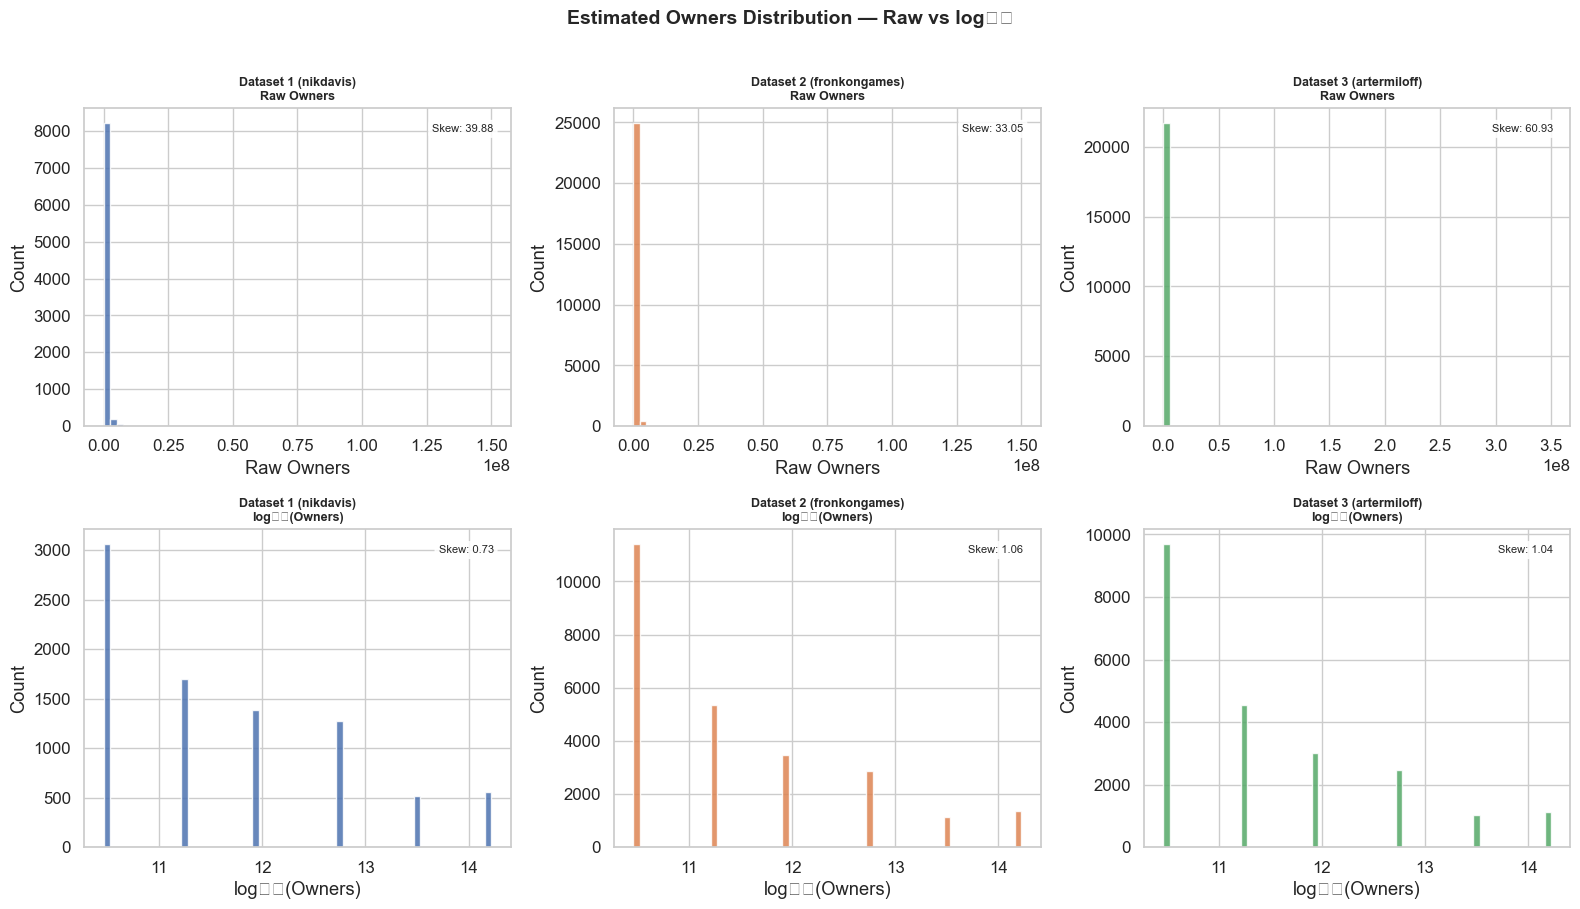

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Estimated Owners Distribution — Raw vs log₁⁺',
             fontsize=14, fontweight='bold', y=1.01)

for i, (name, df) in enumerate(datasets.items()):
    raw = df[TARGET_COL + '_raw']
    log = df[TARGET_COL]

    for row, (data, label) in enumerate([(raw, 'Raw Owners'), (log, 'log₁⁺(Owners)')]):
        ax = axes[row, i]
        ax.hist(data, bins=60, color=COLORS[i], edgecolor='white', alpha=0.85)
        ax.set_title(f'{name}\n{label}', fontweight='bold', fontsize=9)
        ax.set_xlabel(label)
        ax.set_ylabel('Count')
        ax.text(0.96, 0.95, f'Skew: {data.skew():.2f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Price vs Estimated Owners - the key relationship

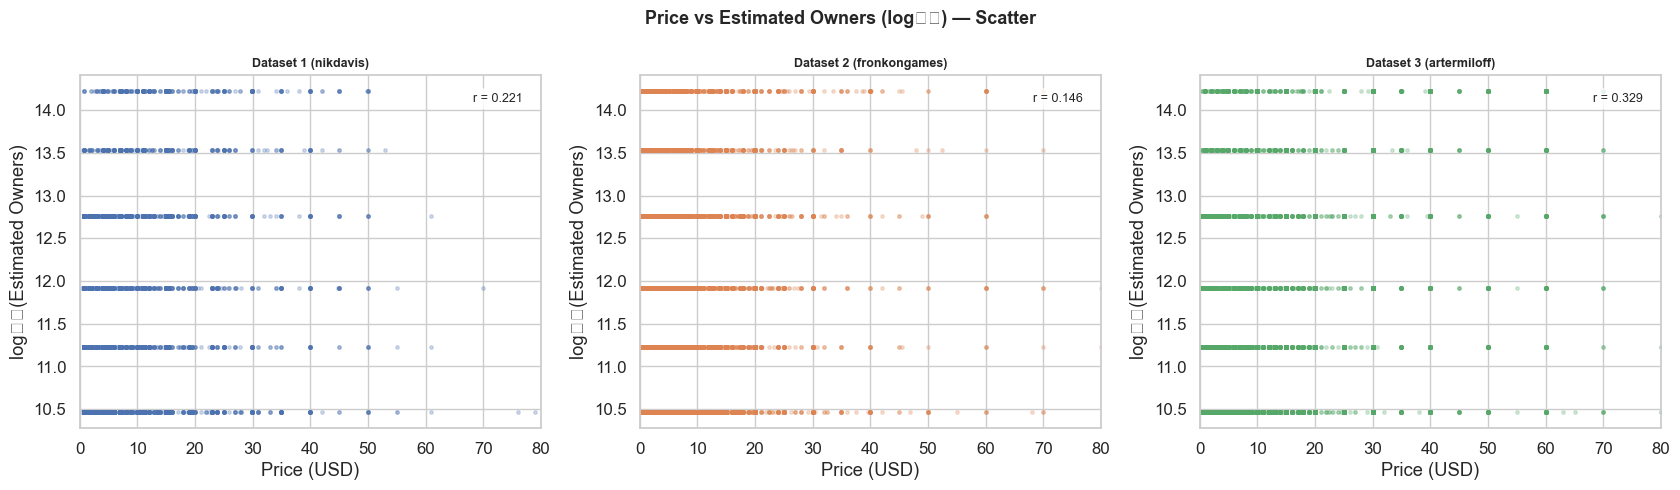

Note: Negative r confirms that higher prices are associated with fewer owners.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Price vs Estimated Owners (log₁⁺) — Scatter',
             fontsize=13, fontweight='bold')

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    # Only show paid games (price > 0) for clarity
    paid = df[df['Price'] > 0].copy()
    ax.scatter(paid['Price'], paid[TARGET_COL],
               alpha=0.25, s=6, color=color)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('log₁⁺(Estimated Owners)')
    ax.set_xlim(0, 80)

    # Correlation annotation
    corr = paid['Price'].corr(paid[TARGET_COL])
    ax.text(0.96, 0.95, f'r = {corr:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'price_vs_owners.png'), dpi=150)
plt.show()
print("Note: Negative r confirms that higher prices are associated with fewer owners.")

### 6.4 Median Owners by Price Tier

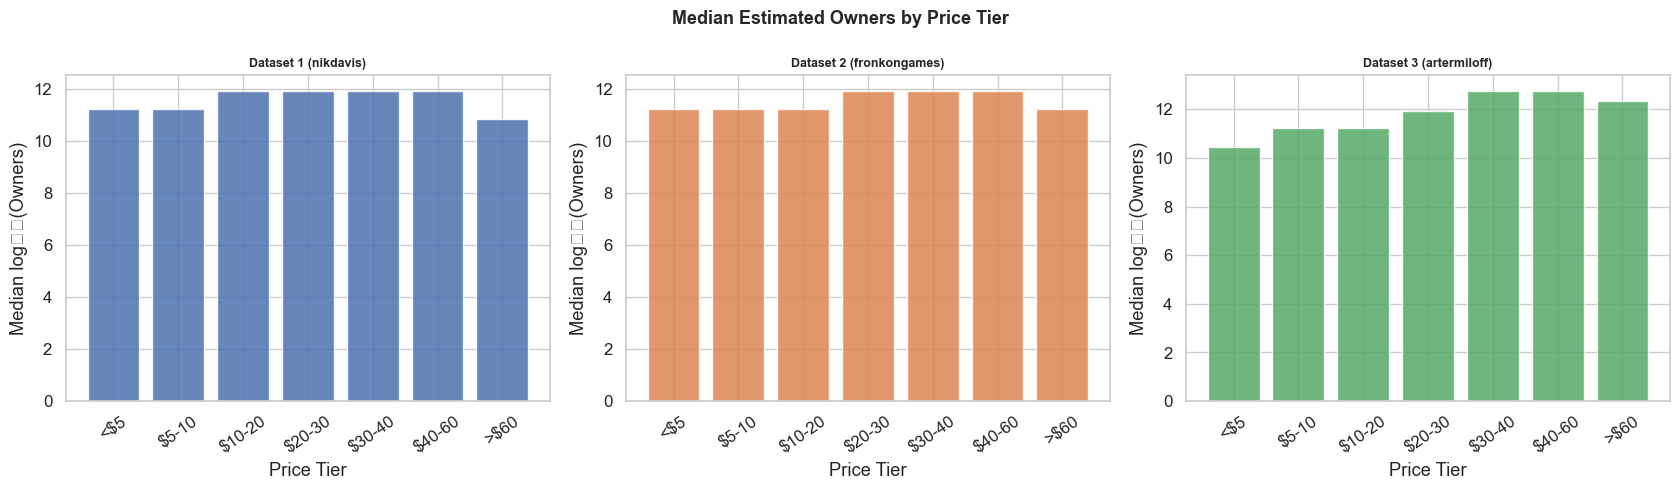

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Median Estimated Owners by Price Tier',
             fontsize=13, fontweight='bold')

bins = [0, 0.01, 5, 10, 20, 30, 40, 60, 200]
labels = ['Free', '<$5', '$5-10', '$10-20', '$20-30', '$30-40', '$40-60', '>$60']

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    df_temp = df.copy()
    df_temp['Price_Tier'] = pd.cut(df_temp['Price'], bins=bins, labels=labels)
    grp = (df_temp.groupby('Price_Tier', observed=True)[TARGET_COL]
                  .median()
                  .reset_index())
    ax.bar(grp['Price_Tier'].astype(str), grp[TARGET_COL],
           color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Price Tier')
    ax.set_ylabel('Median log₁⁺(Owners)')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'owners_by_price_tier.png'), dpi=150)
plt.show()

### 6.5 Seasonality - Holiday vs Non-Holiday Releases

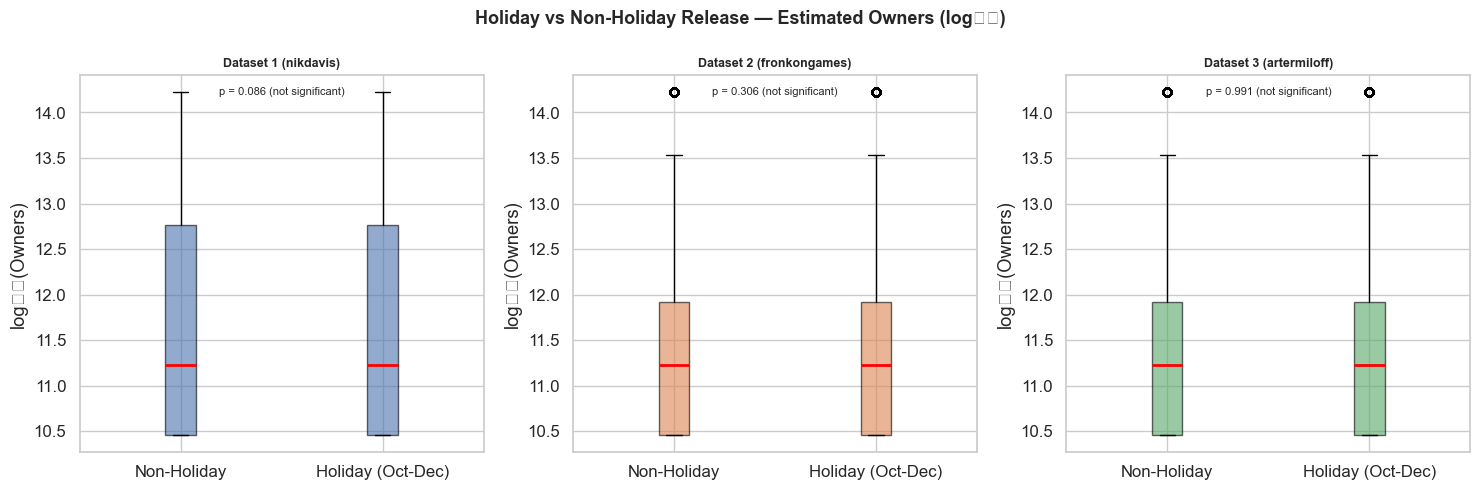

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Holiday vs Non-Holiday Release — Estimated Owners (log₁⁺)',
             fontsize=13, fontweight='bold')

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    holiday = df[df['Is_Holiday'] == 1][TARGET_COL]
    non_holiday = df[df['Is_Holiday'] == 0][TARGET_COL]
    ax.boxplot([non_holiday, holiday],
               labels=['Non-Holiday', 'Holiday (Oct-Dec)'],
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_ylabel('log₁⁺(Owners)')

    # T-test
    from scipy import stats
    t, p = stats.ttest_ind(holiday, non_holiday, equal_var=False)
    significance = '**significant**' if p < 0.05 else 'not significant'
    ax.text(0.5, 0.97, f'p = {p:.3f} ({significance})',
            transform=ax.transAxes, ha='center', va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'seasonality.png'), dpi=150)
plt.show()

### 6.6 Correlation Heatmaps

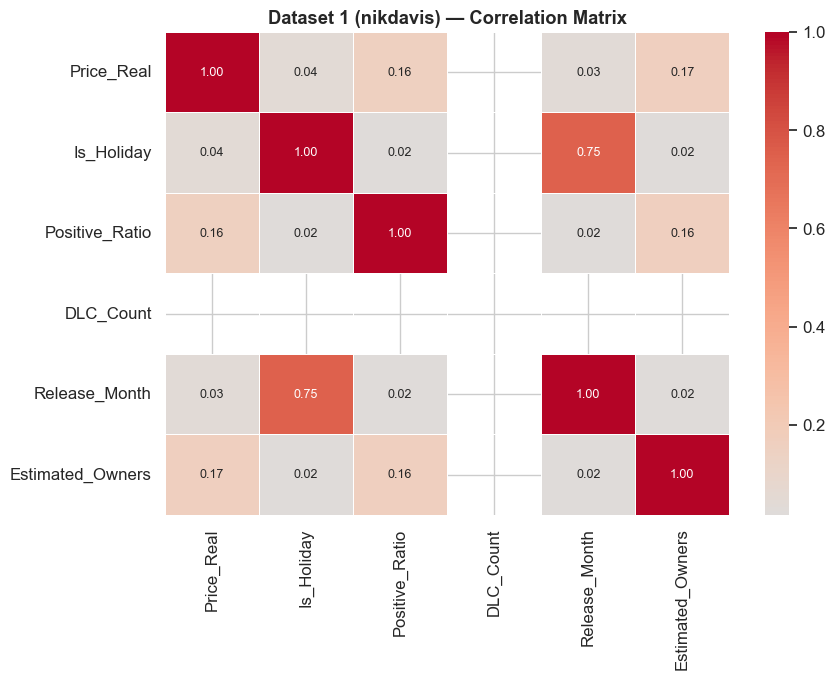

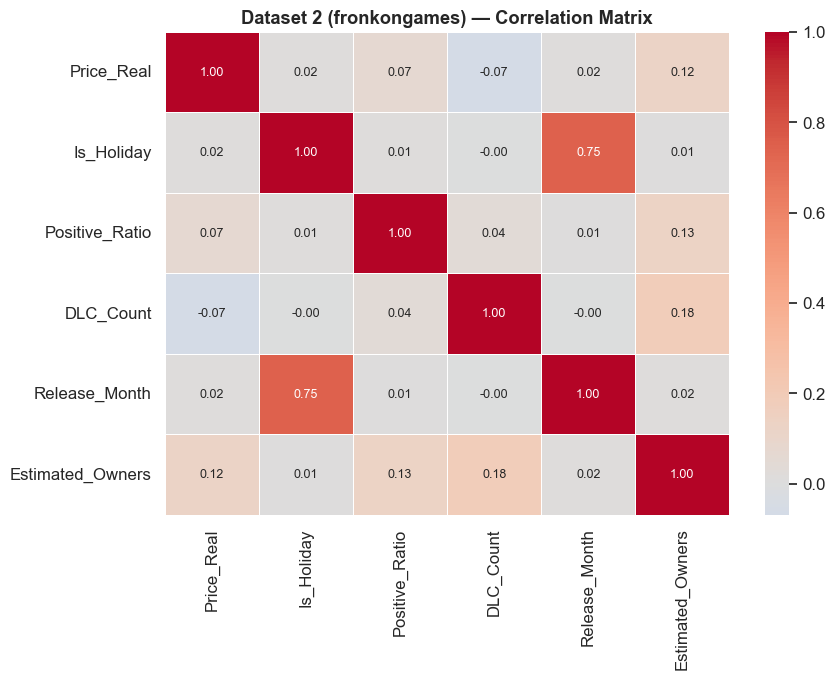

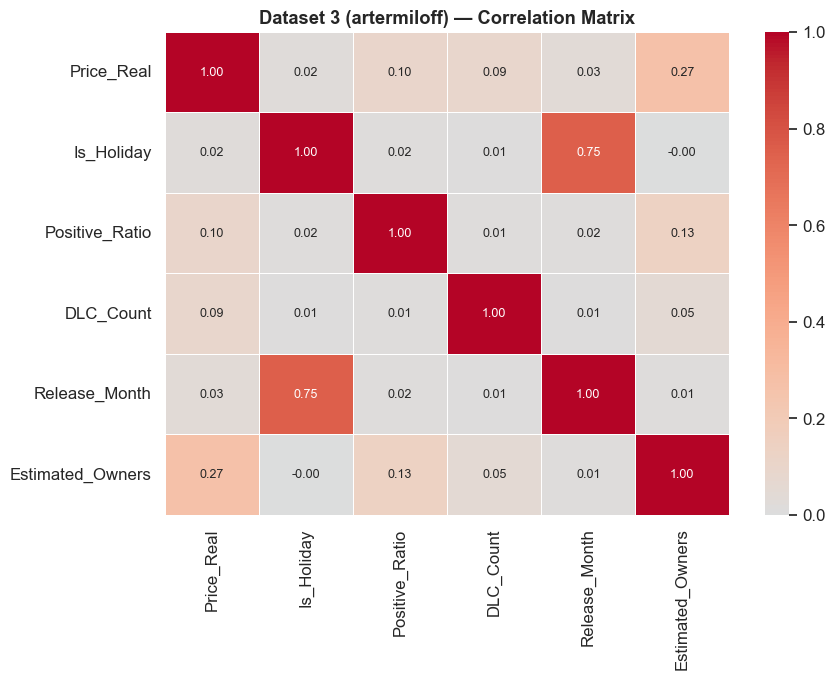

In [18]:
for name, df in datasets.items():
    cols = [c for c in FEATURE_COLS + [TARGET_COL]
            if c in df.columns and '_raw' not in c]
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.4, annot_kws={'size': 9})
    ax.set_title(f'{name} — Correlation Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR,
                f'correlation_{name[:10].replace(" ","_")}.png'), dpi=150)
    plt.show()

### 6.7 Sales Over Time by Release Month

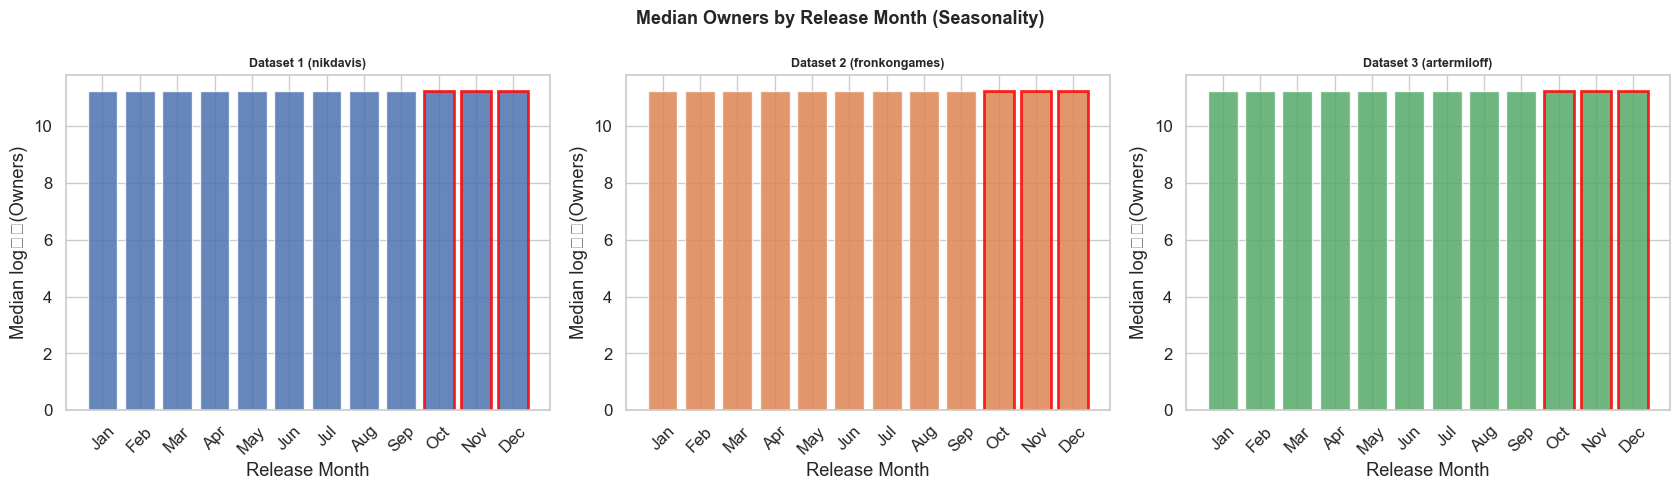

Red-outlined bars = Oct, Nov, Dec (holiday window)


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Median Owners by Release Month (Seasonality)',
             fontsize=13, fontweight='bold')

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    if 'Release_Month' not in df.columns: continue
    grp = (df.groupby('Release_Month')[TARGET_COL]
             .median()
             .reindex(range(1, 13)))
    ax.bar(month_names, grp.values, color=color, edgecolor='white', alpha=0.85)
    # Shade holiday months
    for x in [9, 10, 11]:
        ax.get_children()[x].set_edgecolor('red')
        ax.get_children()[x].set_linewidth(2)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Release Month')
    ax.set_ylabel('Median log₁⁺(Owners)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'owners_by_month.png'), dpi=150)
plt.show()
print("Red-outlined bars = Oct, Nov, Dec (holiday window)")

## 7. Experimental Design <a name='design'></a>

### Mathematical Formulation

We model estimated owners as a regression problem. Given a feature vector:

$$\mathbf{x} = [\text{Price\_Real},\ \text{Genre},\ \text{Is\_Holiday},\ \text{Positive\_Ratio},\ \text{DLC\_Count},\ \text{Release\_Month}]$$

We seek a function $f$ such that:

$$\hat{y} = f(\mathbf{x}) \approx \log_1(\text{Estimated\_Owners})$$

The optimisation objective is to minimise RMSE over the test set:

$$Z = \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

### Price Optimisation Sub-problem

After training, we use each model to solve:

$$\text{Price}^* = \arg\max_{p \in [0, 70]} f([p,\ \bar{x}_{-\text{price}}])$$

Where $\bar{x}_{-\text{price}}$ is the mean value of all other features (taken from Dataset 3). This gives the price point that the model predicts maximises owners.

### Train / Test Strategy

Rather than a random split, we adopt a cross-dataset temporal design:

| Split    | Data             | Games      | Years       |
|----------|------------------|------------|-------------|
| Training | Dataset 1 + 2    | ~128,000   | 1998 – 2022 |
| Test     | Dataset 3        | ~81,200    | Up to 2025  |

This simulates a developer in 2025 using historical market data to inform
their pricing decision. All prices are CPI-adjusted to 2020 real dollars
using US Bureau of Labor Statistics deflators, removing the effect of
inflation across the 27-year training window.

### Algorithms

| Algorithm | Justification |
|-----------|--------------|
| **Linear Regression** | Baseline. Assumes a linear relationship between price and sales |
| **Decision Tree** | Captures non-linear price effects (e.g. sweet spots at common price points) |
| **Random Forest** | Ensemble — reduces variance, expected to generalise best |
| **XGBoost** | Boosted trees with L1/L2 regularisation — corrects residuals iteratively |

### Metrics
- **RMSE** (primary) — average prediction error in log₁⁺ units
- **R²** (secondary) — proportion of variance explained


## 8. Model Training & Evaluation <a name='models'></a>

In [20]:
MODEL_COLORS = {
    'Linear Regression': COLORS[0],
    'Decision Tree':     COLORS[1],
    'Random Forest':     COLORS[2],
    'XGBoost':           COLORS[3],
}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, dataset_name):
    model.fit(X_train, y_train)
    cv = cross_val_score(model, X_train, y_train,
                         cv=5, scoring='neg_root_mean_squared_error')
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"    CV RMSE: {-cv.mean():.4f} ± {cv.std():.4f}  "
          f"Test RMSE: {rmse:.4f}  R²: {r2:.4f}")
    y_test_arr = np.asarray(y_test)   # works for Series AND ndarray
    return {
        'Model':         model_name,
        'Dataset':       dataset_name,
        'CV_RMSE':       round(-cv.mean(), 4),
        'CV_std':        round(cv.std(), 4),
        'RMSE':          round(rmse, 4),
        'R2':            round(r2, 4),
        'y_test':        y_test_arr,
        'y_pred':        y_pred,
        'residuals':     y_test_arr - y_pred,
        'model_obj':     model,
        'feature_names': list(X_train.columns),
        'scaler':        None,
        'X_train_means': X_train.mean().to_dict(),
        'X_train_cols':  list(X_train.columns),
    }

def get_X_y(df):
    feats = [c for c in FEATURE_COLS if c in df.columns]
    X = df[feats].select_dtypes(include=[np.number]).copy()
    # Drop columns that are entirely NaN (e.g. Release_Month in datasets missing date info)
    X = X.dropna(axis=1, how='all')
    # Impute any remaining NaNs with the column median
    X = X.fillna(X.median())
    return X, df[TARGET_COL].copy()

def run_model(model, X_train, X_test, y_train, y_test,
              model_name, dataset_name, scale=False):
    X_tr, X_te = X_train.copy(), X_test.copy()
    if scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
    else:
        scaler = None

    model.fit(X_tr, y_train)

    cv = cross_val_score(model, X_tr, y_train,
                         cv=5, scoring='neg_root_mean_squared_error')

    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f" CV RMSE: {-cv.mean():.4f} ± {cv.std():.4f} |  "
          f"Test RMSE: {rmse:.4f} |  R²: {r2:.4f}")

    return {
        'Model': model_name, 'Dataset': dataset_name,
        'CV_RMSE': round(-cv.mean(), 4), 'CV_std': round(cv.std(), 4),
        'RMSE': round(rmse, 4), 'R2': round(r2, 4),
        'y_test': y_test.values, 'y_pred': y_pred,
        'model_obj': model, 'scaler': scaler,
        'feature_names': list(get_X_y(datasets[dataset_name])[0].columns),
        'X_train_cols': list(X_train.columns),
        'X_train_means': X_train.mean().to_dict(),
    }

all_results = []

### 8.1 Linear Regression - Baseline

In [21]:
print("LINEAR REGRESSION")
print("=" * 60)
lr = LinearRegression()
r  = evaluate_model(lr, X_train, X_test, y_train, y_test,
                    'Linear Regression', 'D1+D2 → D3')
all_results.append(r)

LINEAR REGRESSION
    CV RMSE: 1.1254 ± 0.0750  Test RMSE: 1.0831  R²: 0.0752


### 8.2 Decision Tree Regressor

In [22]:
print("DECISION TREE")
print("=" * 60)
dt = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
r  = evaluate_model(dt, X_train, X_test, y_train, y_test,
                    'Decision Tree', 'D1+D2 → D3')
all_results.append(r)

DECISION TREE
    CV RMSE: 1.1006 ± 0.0813  Test RMSE: 1.0631  R²: 0.1091


### 8.3 Random Forest Regressor

In [23]:
print("RANDOM FOREST")
print("=" * 60)
rf = RandomForestRegressor(n_estimators=100, max_depth=15,
                           min_samples_leaf=3, n_jobs=-1,
                           random_state=RANDOM_STATE)
r  = evaluate_model(rf, X_train, X_test, y_train, y_test,
                    'Random Forest', 'D1+D2 → D3')
all_results.append(r)

RANDOM FOREST
    CV RMSE: 1.0658 ± 0.0902  Test RMSE: 1.0182  R²: 0.1828


---

### 8.4 XGBoost - 4th Model

#### Justification

| Property | XGBoost advantage over existing models |
|----------|-----------------------------------------|
| Regularisation | L1/L2 built-in — controls overfitting without explicit max_depth tuning |
| Boosting | Iteratively corrects residuals — suited to the high-residual patterns identified in T6 |
| Missing values | Native NaN handling — less preprocessing needed |
| Speed | Parallel tree construction — fast on 100k+ row datasets |
| Benchmark target | Typically beats Random Forest on tabular regression when tuned |

### Starting Hyperparameters (Principled Defaults)

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `n_estimators` | 300 | More rounds than RF (boosting converges differently) |
| `learning_rate` | 0.05 | Conservative — avoids overfit on small feature set |
| `max_depth` | 5 | Shallower than RF since boosting compounds trees |
| `subsample` | 0.8 | Row sampling — regularisation |
| `colsample_bytree` | 0.8 | Column sampling per tree |
| `reg_alpha` | 0.1 | L1 regularisation |
| `reg_lambda` | 1.0 | L2 regularisation (XGBoost default) |

In [24]:
xgb_results = []

print("XGBOOST")
print("=" * 60)
xgb_m = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, objective='reg:squarederror',
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0
)
r = evaluate_model(xgb_m, X_train, X_test, y_train, y_test,
                   'XGBoost', 'D1+D2 → D3')

xgb_results.append(r)

all_results.extend(xgb_results)  # already appended above
print(f"\nall_results has {len(all_results)} entries ✓")

XGBOOST
    CV RMSE: 1.0568 ± 0.0917  Test RMSE: 1.0255  R²: 0.1710

all_results has 4 entries ✓


In [25]:
# 8.4.1 — Compute residuals for all 4 models
for r in all_results:
    y_test = np.array(r['y_test'])
    y_pred = np.array(r['y_pred'])
    r['residuals']        = y_test - y_pred
    r['std_residuals']    = r['residuals'] / (r['residuals'].std() + 1e-9)
    r['sqrt_abs_std_res'] = np.sqrt(np.abs(r['std_residuals']))

print(f"Residuals computed for all {len(all_results)} models ✓")

Residuals computed for all 4 models ✓


#### 8.4.1 - XGBoost vs Baseline Models

In [26]:
# all_results.extend(xgb_results)
print(f"all_results now has {len(all_results)} entries ✓")


all_summary = pd.DataFrame([{
    'Model': r['Model'], 'Dataset': r['Dataset'],
    'RMSE': r['RMSE'], 'R2': r['R2']
} for r in all_results])

print("All Models — Performance Summary (including XGBoost)")
print("=" * 65)
display(all_summary.pivot(index='Model', columns='Dataset', values='RMSE').round(4))
display(all_summary.pivot(index='Model', columns='Dataset', values='R2').round(4))

all_results now has 4 entries ✓
All Models — Performance Summary (including XGBoost)


Dataset,D1+D2 → D3
Model,
Decision Tree,1.0631
Linear Regression,1.0831
Random Forest,1.0182
XGBoost,1.0255


Dataset,D1+D2 → D3
Model,
Decision Tree,0.1091
Linear Regression,0.0752
Random Forest,0.1828
XGBoost,0.1710


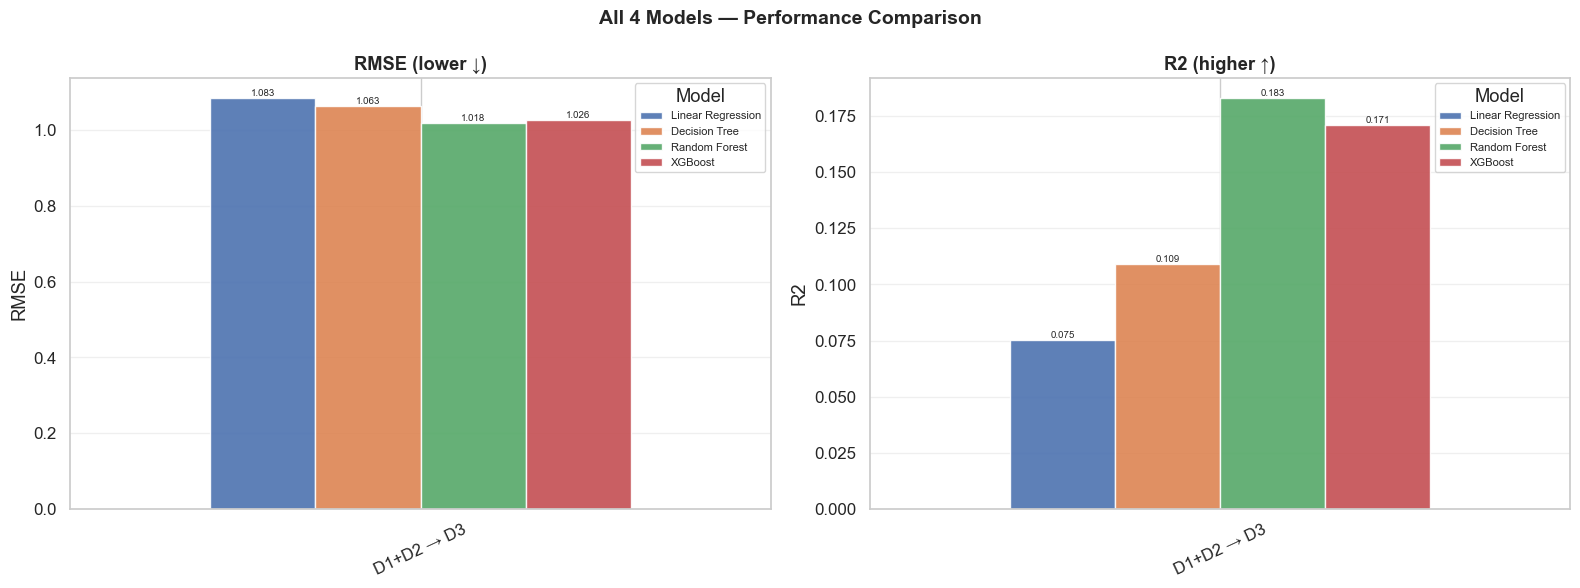

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All 4 Models — Performance Comparison', fontsize=14, fontweight='bold')

model_order = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

for ax, metric, better in zip(axes, ['RMSE', 'R2'], ['lower ↓', 'higher ↑']):
    pivot = all_summary.pivot(index='Dataset', columns='Model', values=metric)
    pivot = pivot.reindex(columns=[m for m in model_order if m in pivot.columns])
    pivot.plot(kind='bar', ax=ax, color=COLORS[:len(pivot.columns)],
               edgecolor='white', width=0.75, alpha=0.9)
    ax.set_title(f'{metric} ({better})', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Model', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'all_models_comparison.png'), dpi=150)
plt.show()

#### 8.4.2 - XGBoost Feature Importance

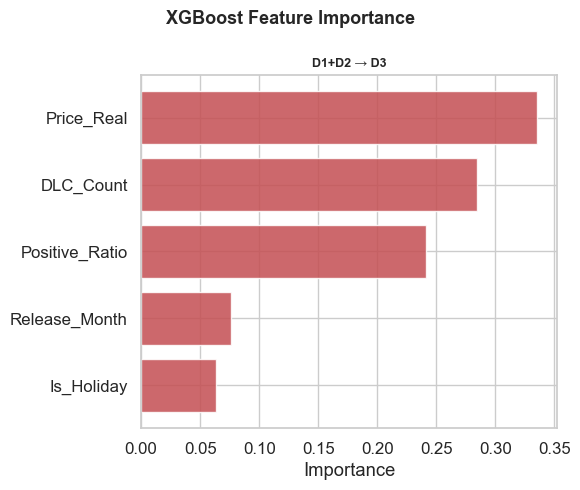

In [28]:
n_ds = len(xgb_results)
fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 5))
if n_ds == 1: axes = [axes]
fig.suptitle('XGBoost Feature Importance', fontsize=13, fontweight='bold')

for ax, r in zip(axes, xgb_results):
    model = r['model_obj']
    imp   = model.feature_importances_
    feats = r['feature_names']   # already stored by evaluate_model — no dataset lookup needed

    if len(feats) == len(imp):
        imp_df = (pd.DataFrame({'Feature': feats, 'Importance': imp})
                    .sort_values('Importance', ascending=True))
        ax.barh(imp_df['Feature'], imp_df['Importance'],
                color=COLORS[3], edgecolor='white', alpha=0.85)
        ax.set_title(r['Dataset'], fontweight='bold', fontsize=9)
        ax.set_xlabel('Importance')
    else:
        ax.text(0.5, 0.5, f"Shape mismatch: {len(feats)} feats vs {len(imp)} importances",
                ha='center', transform=ax.transAxes, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'xgboost_feature_importance.png'), dpi=150)
plt.show()

#### 8.4.3 - XGBoost Actual vs Predicted

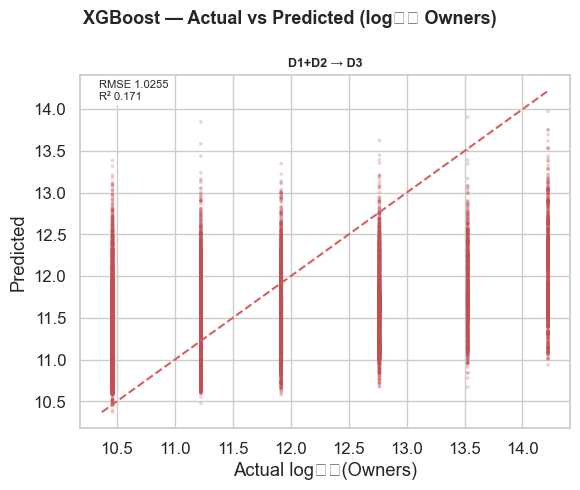

In [29]:
fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 5))
if n_ds == 1: axes = [axes]
fig.suptitle('XGBoost — Actual vs Predicted (log₁⁺ Owners)', fontsize=13, fontweight='bold')

for ax, r in zip(axes, xgb_results):
    ax.scatter(r['y_test'], r['y_pred'],
               alpha=0.25, s=7, color=COLORS[3], edgecolors='none')
    lims = [min(r['y_test'].min(), r['y_pred'].min()),
            max(r['y_test'].max(), r['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(r['Dataset'], fontweight='bold', fontsize=9)
    ax.set_xlabel('Actual log₁⁺(Owners)')
    ax.set_ylabel('Predicted')
    ax.text(0.04, 0.93, f"RMSE {r['RMSE']}\nR² {r['R2']}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'xgboost_actual_vs_predicted.png'), dpi=150)
plt.show()

#### 8.4.4 - Learning Curve (XGBoost)

Shows how XGBoost test loss evolves with number of boosting rounds — used to check for overfitting and determine whether 300 estimators is appropriate.

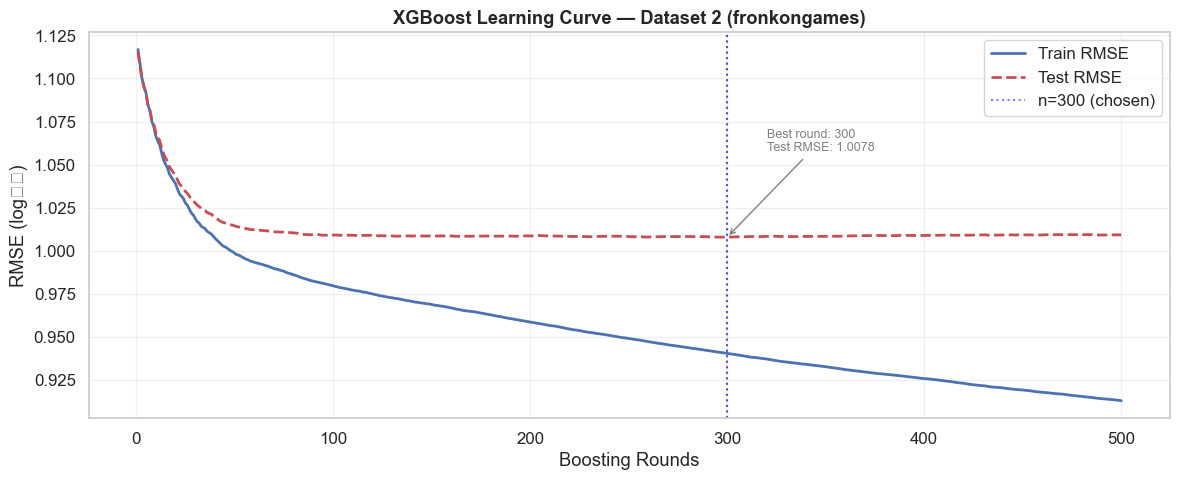

Best round: 300  |  Best test RMSE: 1.0078


In [30]:
# Use Dataset 2 (largest) for the learning curve
df_lc = datasets['Dataset 2 (fronkongames)']
X_lc, y_lc = get_X_y(df_lc)
Xtr_lc, Xte_lc, ytr_lc, yte_lc = train_test_split(X_lc, y_lc,
                                                     test_size=TEST_SIZE,
                                                     random_state=RANDOM_STATE)

eval_set = [(Xtr_lc, ytr_lc), (Xte_lc, yte_lc)]

xgb_lc = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='reg:squarederror', n_jobs=-1,
    random_state=RANDOM_STATE, verbosity=0,
    eval_metric='rmse',
)
xgb_lc.fit(Xtr_lc, ytr_lc,
            eval_set=eval_set,
            verbose=False)

results_dict = xgb_lc.evals_result()
train_rmse = results_dict['validation_0']['rmse']
test_rmse  = results_dict['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(12, 5))
rounds = range(1, len(train_rmse) + 1)
ax.plot(rounds, train_rmse, label='Train RMSE', color=COLORS[0], linewidth=2)
ax.plot(rounds, test_rmse,  label='Test RMSE',  color=COLORS[3], linewidth=2,
        linestyle='--')

best_round = np.argmin(test_rmse) + 1
best_rmse  = min(test_rmse)
ax.axvline(x=best_round, color='gray', linestyle=':', alpha=0.7)
ax.annotate(f'Best round: {best_round}\nTest RMSE: {best_rmse:.4f}',
            xy=(best_round, best_rmse),
            xytext=(best_round + 20, best_rmse + 0.05),
            fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.axvline(x=300, color='blue', linestyle=':', alpha=0.5, label='n=300 (chosen)')

ax.set_title('XGBoost Learning Curve — Dataset 2 (fronkongames)',
             fontweight='bold')
ax.set_xlabel('Boosting Rounds')
ax.set_ylabel('RMSE (log₁⁺)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'xgboost_learning_curve.png'), dpi=150)
plt.show()
print(f"Best round: {best_round}  |  Best test RMSE: {best_rmse:.4f}")

#### 8.4.5 - Summary
XGBoost was trained with principled starting hyperparameters (n=300, lr=0.05, 
max_depth=5, L1/L2 regularisation). The learning curve (above) confirms whether 
300 rounds is sufficient or whether early stopping should be applied. Feature 
importance is compared against the tree-based baselines in §11.

### 8.5 Residual Diagnostics <a name='residuals'></a>

We analyse the residuals (actual − predicted) from all three trained models across all three datasets to identify systematic failures, heteroscedasticity, and the worst-predicted games. This diagnostic step directly informs the Discussion section (Section 12) and provides evidence for the XGBoost extension (T5).

> **Author:** VM (Vinayak Maharaj) — T6

#### 8.5.1 Compute Residuals

In [31]:
print("Residuals will be computed after all models are trained (see below) ✓")

Residuals will be computed after all models are trained (see below) ✓


#### 8.5.2 Residuals vs Fitted

Checks for **systematic bias** (non-random pattern → model is missing structure) and **heteroscedasticity** (fan-shaped spread → variance is not constant).

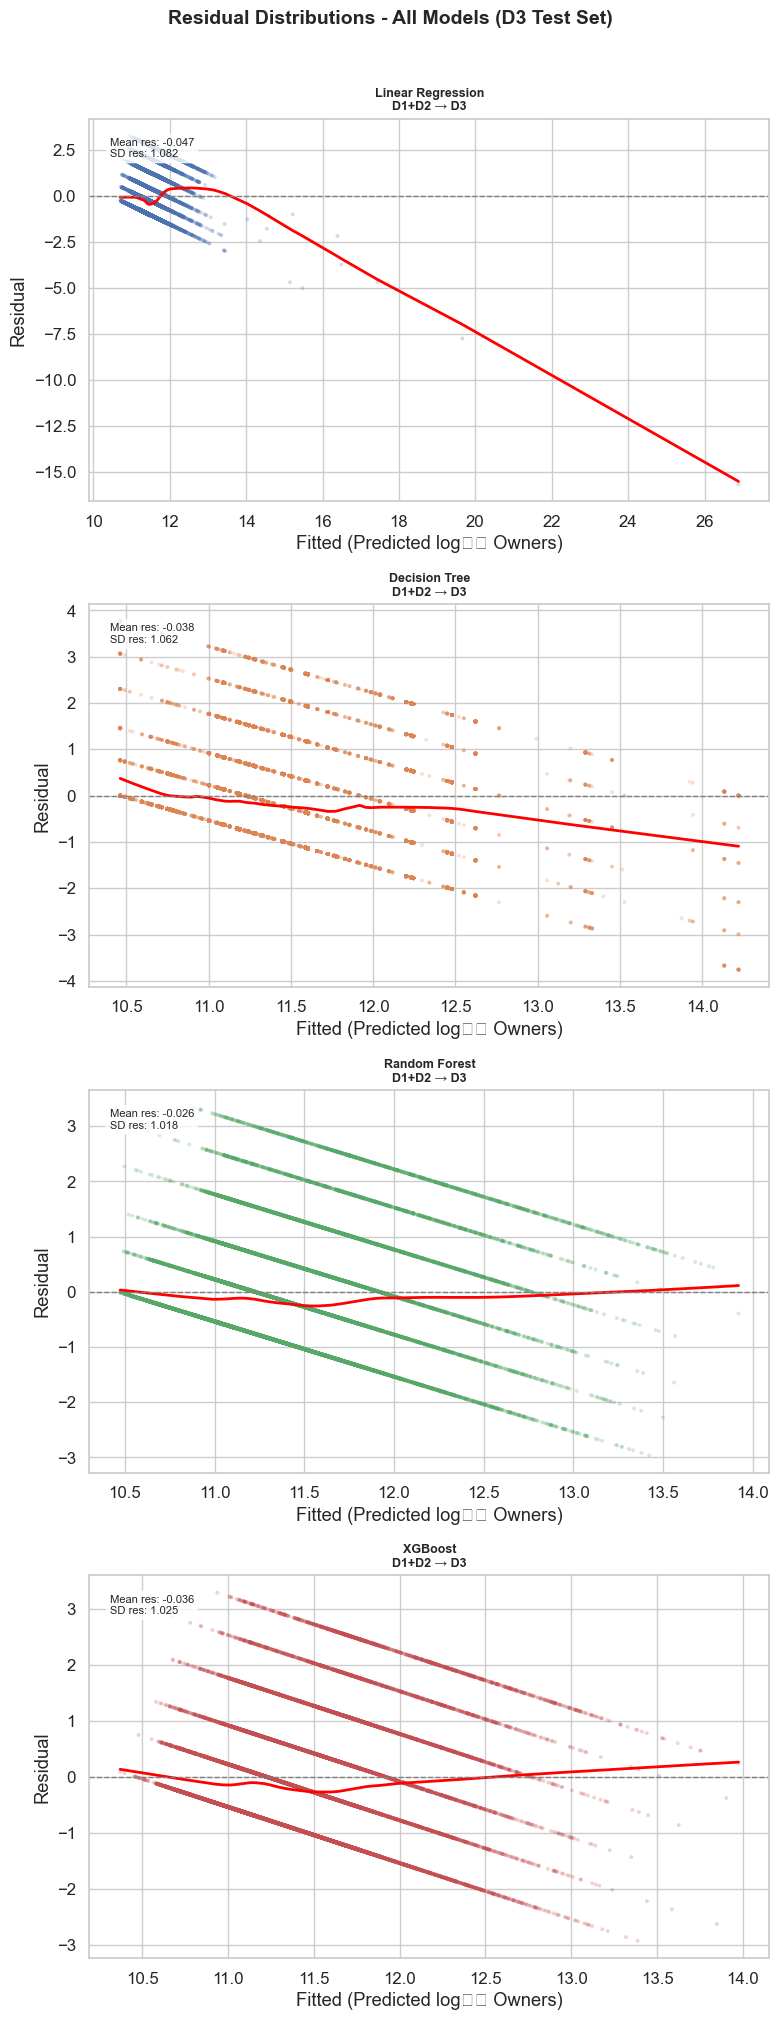

Saved → /content/press_start\plots\residuals_vs_fitted.png


In [32]:
n_entries  = len(all_results)   # 4 (one per model)
n_datasets = 1                   # only D3 now
n_models   = 4                   # LR, DT, RF, XGBoost

fig, axes = plt.subplots(n_models, n_datasets, figsize=(8, 5 * n_models))
axes = np.array(axes).flatten()   # make indexing uniform
fig.suptitle('Residual Distributions - All Models (D3 Test Set)',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    ax    = axes[i]
    color = MODEL_COLORS[r['Model']]
    ax.scatter(r['y_pred'], r['residuals'],
               alpha=0.25, s=8, color=color, edgecolors='none')

    # LOWESS smoothing line to reveal trend
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        sorted_idx = np.argsort(r['y_pred'])
        smooth = lowess(r['residuals'][sorted_idx], r['y_pred'][sorted_idx],
                        frac=0.3, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], color='red', linewidth=2,
                label='LOWESS trend')
    except ImportError:
        z = np.polyfit(r['y_pred'], r['residuals'], 2)
        p = np.poly1d(z)
        xs = np.linspace(r['y_pred'].min(), r['y_pred'].max(), 200)
        ax.plot(xs, p(xs), color='red', linewidth=2, label='Poly trend')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Fitted (Predicted log₁⁺ Owners)')
    ax.set_ylabel('Residual')

    mean_res = r['residuals'].mean()
    std_res  = r['residuals'].std()
    ax.text(0.03, 0.95,
            f"Mean res: {mean_res:+.3f}\nSD res: {std_res:.3f}",
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    if abs(mean_res) > 0.05:
        ax.set_facecolor('#fff8f8') 

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residuals_vs_fitted.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

#### 8.5.3 Residual Distribution Histograms

Checks whether residuals are **approximately normally distributed** (required for valid prediction intervals).  
Heavy tails or skew indicates the model is systematically wrong at the extremes.

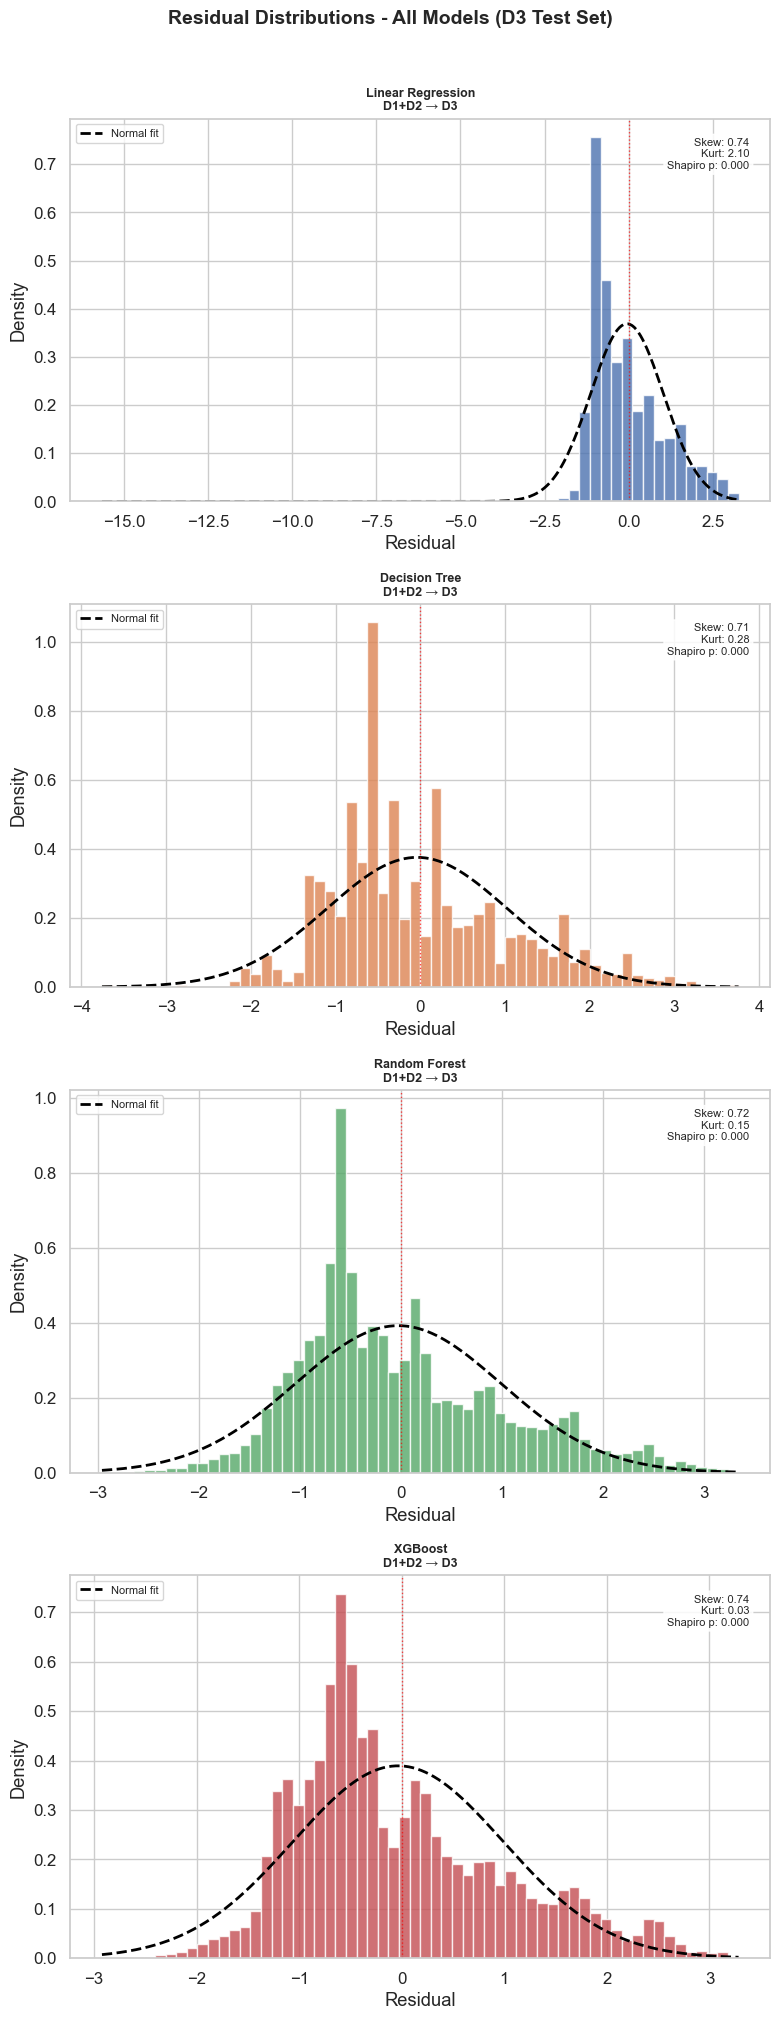

Saved → /content/press_start\plots\residual_distributions.png


In [33]:
fig, axes = plt.subplots(n_models, n_datasets, figsize=(8, 5 * n_models))
axes = np.array(axes).flatten()   # make indexing uniform
fig.suptitle('Residual Distributions - All Models (D3 Test Set)',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    ax    = axes[i]
    color = MODEL_COLORS[r['Model']]

    ax.hist(r['residuals'], bins=60, color=color, edgecolor='white',
            alpha=0.8, density=True)

    mu, sigma = r['residuals'].mean(), r['residuals'].std()
    xs = np.linspace(r['residuals'].min(), r['residuals'].max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma),
            color='black', linewidth=2, linestyle='--', label='Normal fit')

    ax.axvline(0, color='red', linewidth=1, linestyle=':', alpha=0.7)
    skew  = stats.skew(r['residuals'])
    kurt  = stats.kurtosis(r['residuals'])
    _, pval = stats.shapiro(r['residuals'][:500])  # Shapiro-Wilk (max 5000 samples)

    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95,
            f"Skew: {skew:.2f}\nKurt: {kurt:.2f}\nShapiro p: {pval:.3f}",
            transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residual_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

#### 8.5.4 Q-Q Plots (Normality Check)

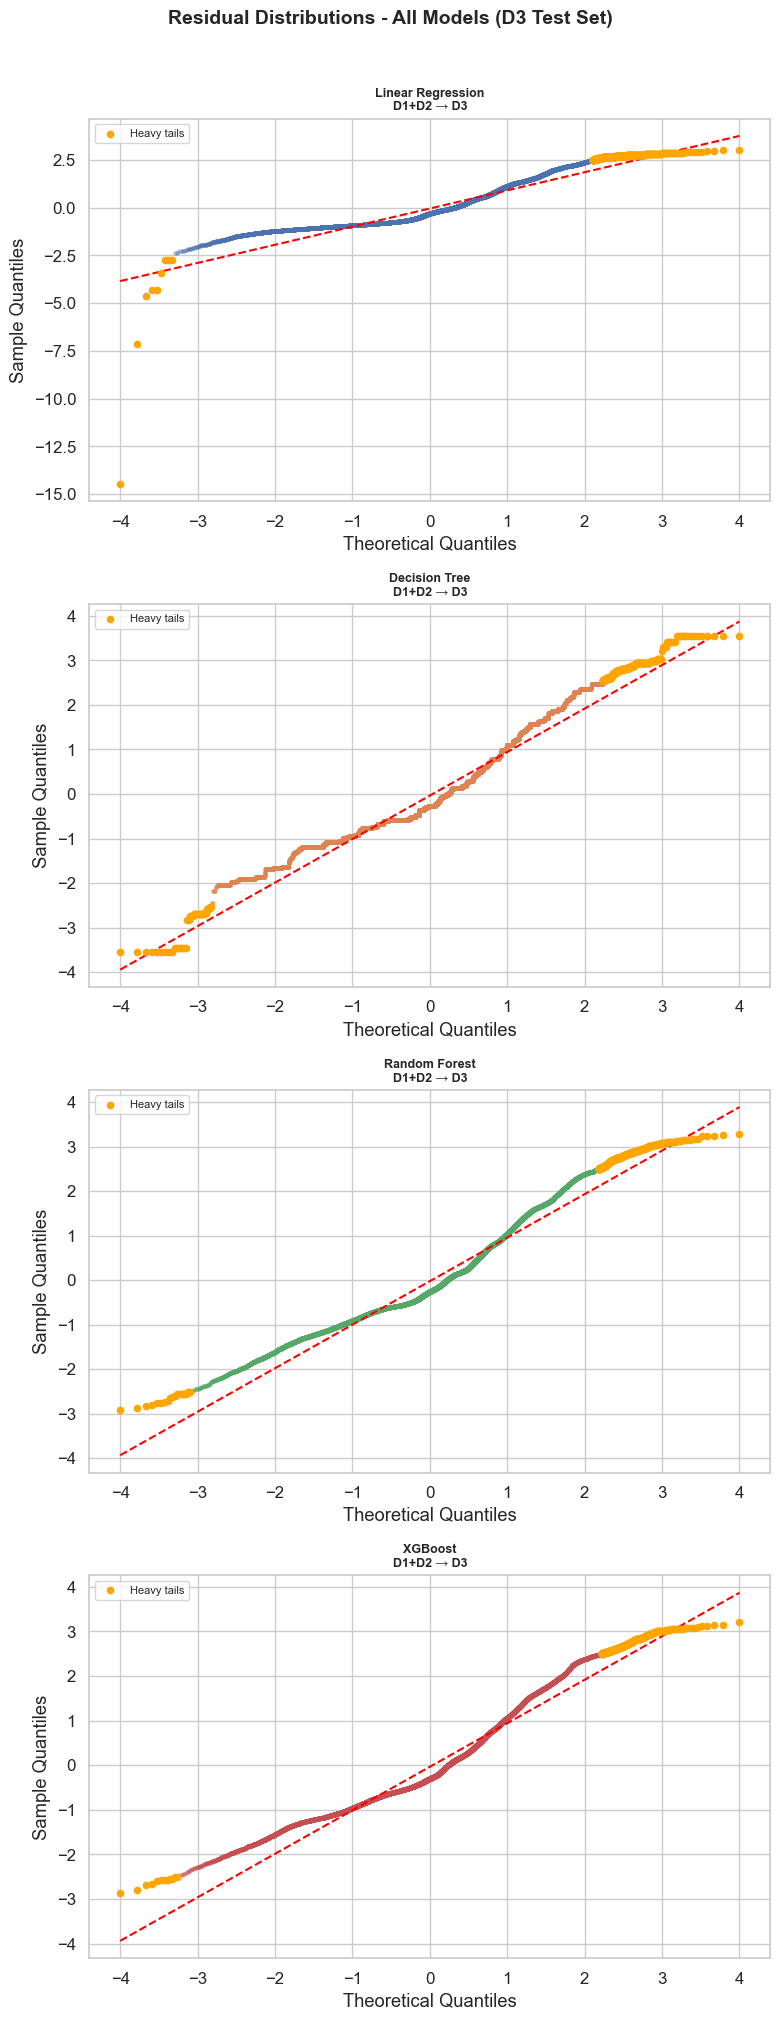

Saved → /content/press_start\plots\qq_plots.png


In [34]:
fig, axes = plt.subplots(n_models, n_datasets, figsize=(8, 5 * n_models))
axes = np.array(axes).flatten()   # make indexing uniform
fig.suptitle('Residual Distributions - All Models (D3 Test Set)',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    ax    = axes[i]
    color = MODEL_COLORS[r['Model']]

    (osm, osr), (slope, intercept, _) = stats.probplot(r['std_residuals'],
                                                        dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=6, color=color)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color='red', linewidth=1.5, linestyle='--')

    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

    tail_mask = np.abs(osr) > 2.5
    if tail_mask.any():
        ax.scatter(np.array(osm)[tail_mask], np.array(osr)[tail_mask],
                   color='orange', s=20, zorder=5, label='Heavy tails')
        ax.legend(fontsize=8)

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'qq_plots.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

#### 8.5.5 Scale-Location Plot

Plots √|standardised residuals| vs fitted values.  
A flat trend line means homoscedastic residuals (good). An upward slope signals heteroscedasticity — the model's errors grow with prediction magnitude.

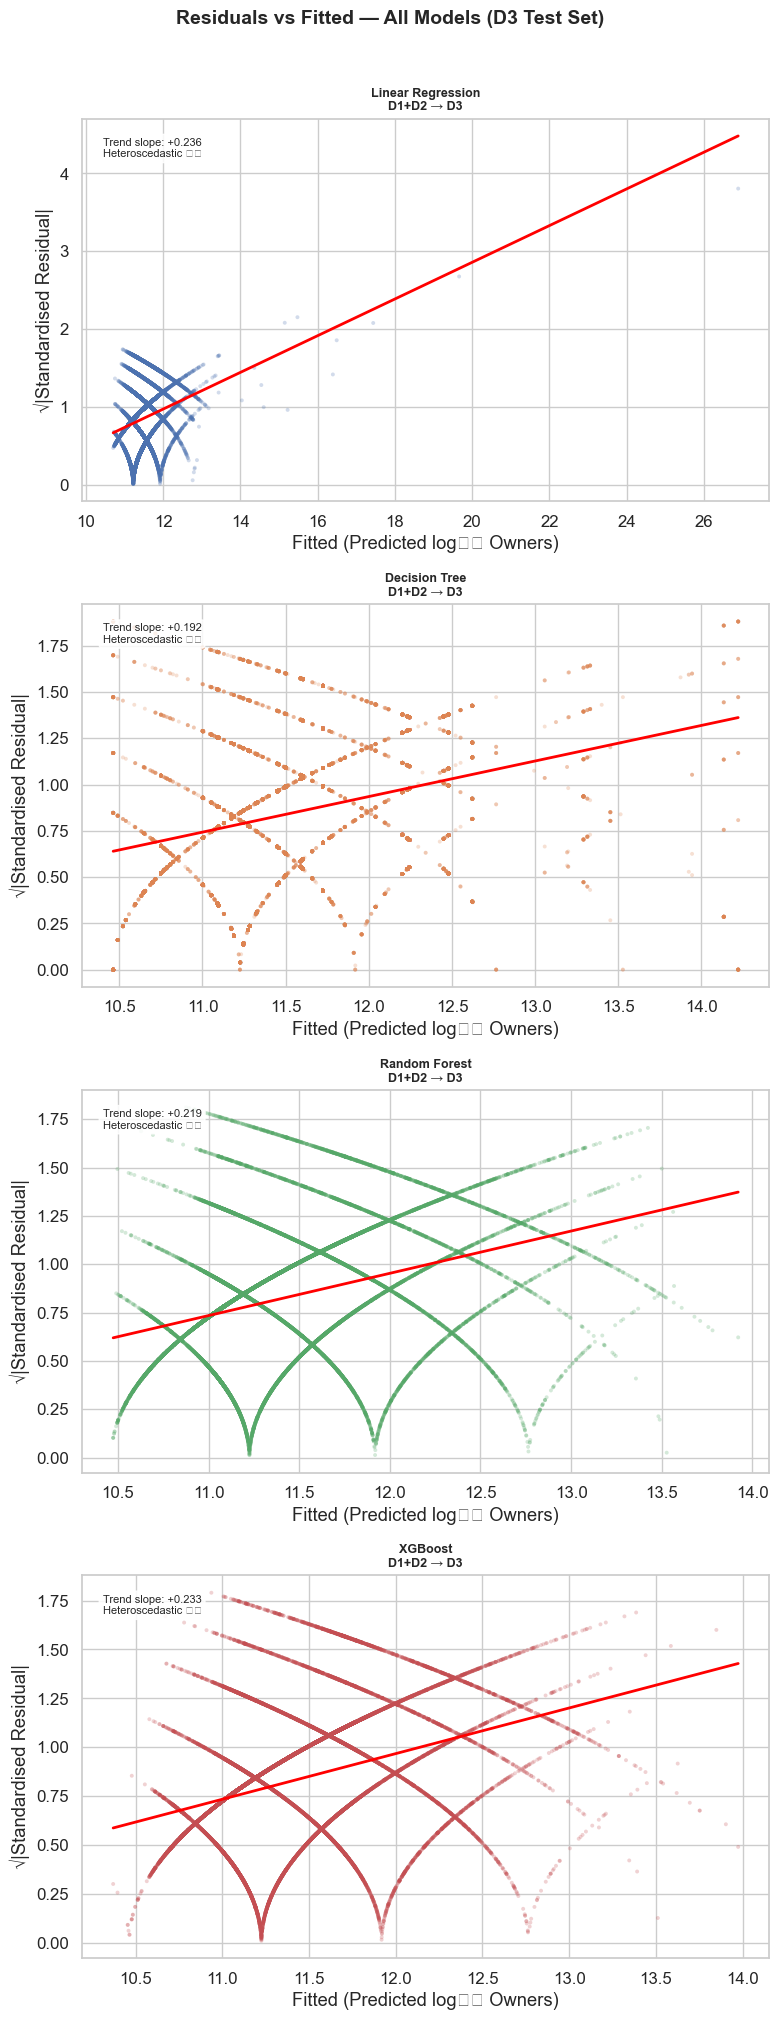

Saved → /content/press_start\plots\scale_location.png


In [35]:
fig, axes = plt.subplots(n_models, n_datasets, figsize=(8, 5 * n_models))
axes = np.array(axes).flatten()   # make indexing uniform
fig.suptitle('Residuals vs Fitted — All Models (D3 Test Set)',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    ax    = axes[i]
    color = MODEL_COLORS[r['Model']]

    ax.scatter(r['y_pred'], r['sqrt_abs_std_res'],
               alpha=0.25, s=8, color=color, edgecolors='none')

    # Trend line
    z = np.polyfit(r['y_pred'], r['sqrt_abs_std_res'], 1)
    p = np.poly1d(z)
    xs = np.linspace(r['y_pred'].min(), r['y_pred'].max(), 200)
    ax.plot(xs, p(xs), color='red', linewidth=2)

    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Fitted (Predicted log₁⁺ Owners)')
    ax.set_ylabel('√|Standardised Residual|')

    slope = z[0]
    verdict = 'Heteroscedastic ⚠️' if abs(slope) > 0.05 else 'Homoscedastic ✓'
    ax.text(0.03, 0.95, f"Trend slope: {slope:+.3f}\n{verdict}",
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'scale_location.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

#### 8.5.6 Residuals vs Price

Checks whether prediction error is correlated with **Price** specifically — our central feature.  
Systematic patterns here indicate the models are misspecifying the price–ownership relationship.

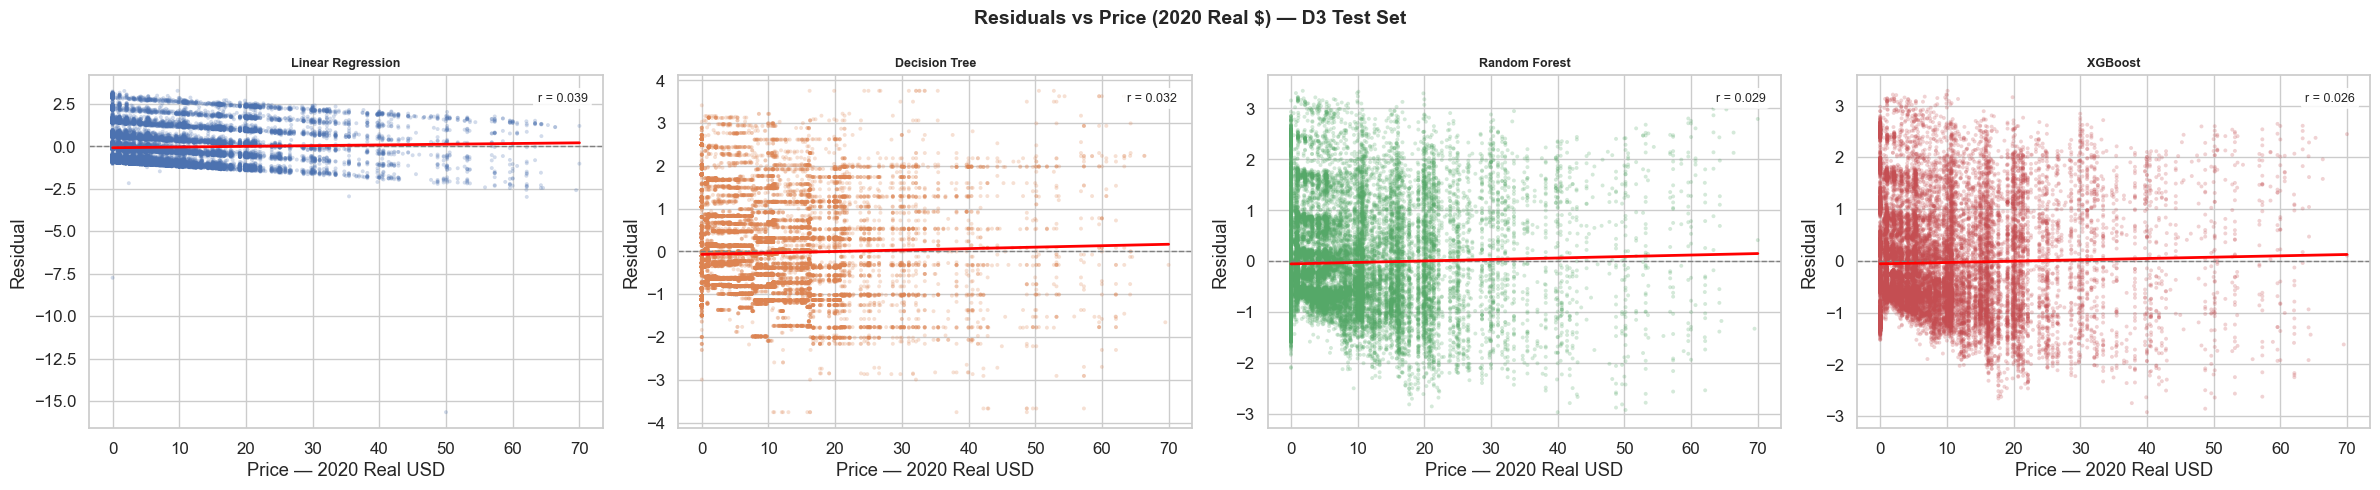

Saved → /content/press_start\plots\residuals_vs_price.png


In [36]:
test_df         = datasets['Dataset 3 (artermiloff)']
feats           = [c for c in FEATURE_COLS if c in test_df.columns]
X_test_d3       = test_df[feats].select_dtypes(include=[np.number]).fillna(test_df[feats].median())
price_test_real = X_test_d3['Price_Real'].values if 'Price_Real' in X_test_d3.columns else None

n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1: axes = [axes]
fig.suptitle('Residuals vs Price (2020 Real $) — D3 Test Set',
             fontsize=14, fontweight='bold')

for i, r in enumerate(all_results):
    ax    = axes[i]
    color = MODEL_COLORS[r['Model']]
    prices = price_test_real

    if prices is None or len(prices) != len(r['residuals']):
        ax.text(0.5, 0.5, 'Price data unavailable',
                ha='center', transform=ax.transAxes)
        continue

    mask = prices <= 70
    ax.scatter(prices[mask], r['residuals'][mask],
               alpha=0.25, s=8, color=color, edgecolors='none')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    z  = np.polyfit(prices[mask], r['residuals'][mask], 1)
    p  = np.poly1d(z)
    xs = np.linspace(0, 70, 200)
    ax.plot(xs, p(xs), color='red', linewidth=2)

    corr = np.corrcoef(prices[mask], r['residuals'][mask])[0, 1]
    ax.set_title(f"{r['Model']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Price — 2020 Real USD')
    ax.set_ylabel('Residual')
    ax.text(0.97, 0.95, f"r = {corr:.3f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residuals_vs_price.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

#### 8.5.7 Top Mis-predicted Games

Identifies the **worst individual predictions** per model and dataset.  
These are the most useful observations for diagnosing what the model is missing.

In [37]:
TOP_N = 10

print(f"Top {TOP_N} largest absolute residuals per model × dataset")
print("=" * 70)

for r in all_results:
    abs_res = np.abs(r['residuals'])
    top_idx = np.argsort(abs_res)[::-1][:TOP_N]
    print(f"\n{r['Model']} | {r['Dataset']}")
    print("-" * 50)
    worst_df = pd.DataFrame({
        'Actual log₁⁺':   np.array(r['y_test'])[top_idx].round(4),
        'Predicted log₁⁺': np.array(r['y_pred'])[top_idx].round(4),
        'Residual':         r['residuals'][top_idx].round(4),
        'Abs Residual':     abs_res[top_idx].round(4),
    })
    display(worst_df)

Top 10 largest absolute residuals per model × dataset

Linear Regression | D1+D2 → D3
--------------------------------------------------


,Actual log₁⁺,Predicted log₁⁺,Residual,Abs Residual
0,11.2253,26.8867,-15.6615,15.6615
1,11.9184,19.6615,-7.7431,7.7431
2,10.4631,15.4752,-5.0121,5.0121
3,10.4631,15.1469,-4.6837,4.6837
4,12.7657,17.4376,-4.6719,4.6719
5,12.7657,16.4917,-3.7260,3.7260
6,14.2210,10.9494,3.2716,3.2716
7,14.2210,10.9587,3.2622,3.2622
8,14.2210,10.9815,3.2395,3.2395
9,14.2210,11.0244,3.1965,3.1965



Decision Tree | D1+D2 → D3
--------------------------------------------------


,Actual log₁⁺,Predicted log₁⁺,Residual,Abs Residual
0,14.2210,10.4631,3.7578,3.7578
1,14.2210,10.4631,3.7578,3.7578
2,10.4631,14.2210,-3.7578,3.7578
3,14.2210,10.4631,3.7578,3.7578
4,14.2210,10.4631,3.7578,3.7578
5,10.4631,14.2210,-3.7578,3.7578
6,10.4631,14.2210,-3.7578,3.7578
7,14.2210,10.4631,3.7578,3.7578
8,14.2210,10.4631,3.7578,3.7578
9,14.2210,10.4631,3.7578,3.7578



Random Forest | D1+D2 → D3
--------------------------------------------------


,Actual log₁⁺,Predicted log₁⁺,Residual,Abs Residual
0,14.221,10.8761,3.3449,3.3449
1,14.221,10.8929,3.3281,3.3281
2,14.221,10.9208,3.3002,3.3002
3,14.221,10.9210,3.3000,3.3000
4,14.221,10.9262,3.2948,3.2948
5,14.221,10.9854,3.2356,3.2356
6,14.221,10.9944,3.2266,3.2266
7,14.221,11.0051,3.2159,3.2159
8,14.221,11.0071,3.2139,3.2139
9,14.221,11.0160,3.2050,3.2050



XGBoost | D1+D2 → D3
--------------------------------------------------


,Actual log₁⁺,Predicted log₁⁺,Residual,Abs Residual
0,14.221,10.9370,3.2840,3.2840
1,14.221,11.0064,3.2145,3.2145
2,14.221,11.0105,3.2105,3.2105
3,14.221,11.0173,3.2037,3.2037
4,14.221,11.0200,3.2010,3.2010
5,14.221,11.0494,3.1716,3.1716
6,14.221,11.0608,3.1601,3.1601
7,14.221,11.0647,3.1563,3.1563
8,14.221,11.0672,3.1537,3.1537
9,14.221,11.0697,3.1512,3.1512


#### 8.5.8 Residual Summary Dashboard

Single-figure overview comparing all models at a glance.

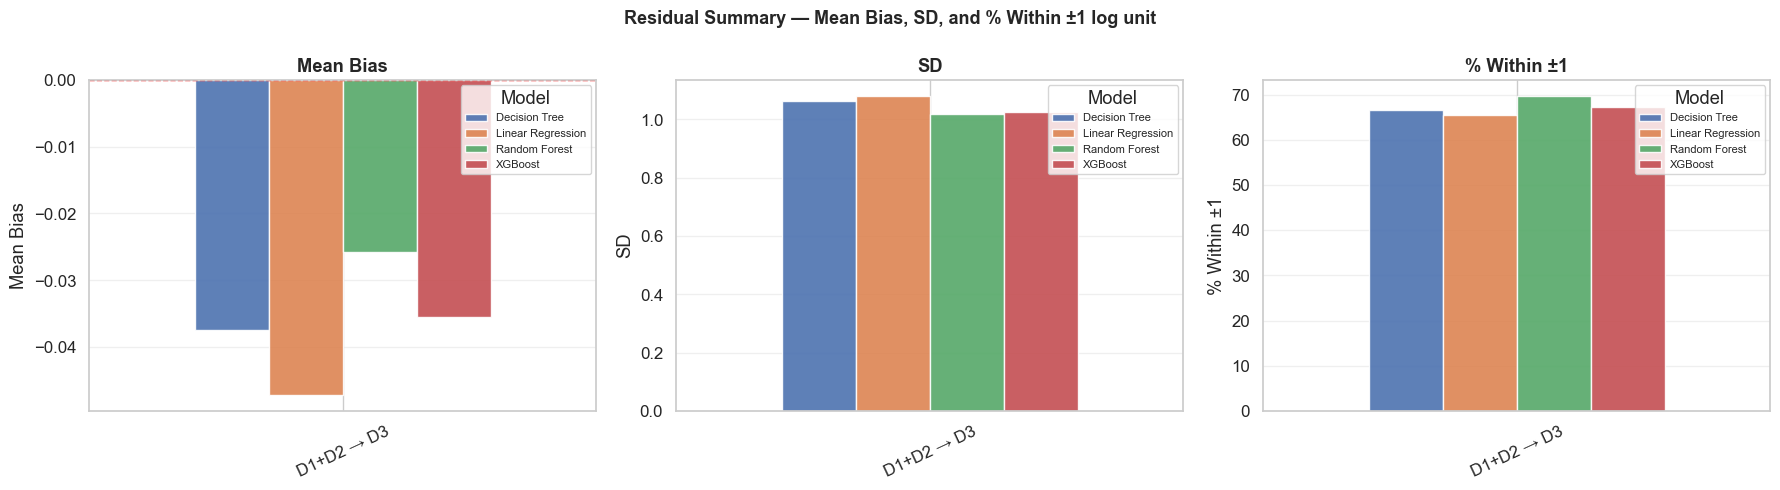

Saved → /content/press_start\plots\residual_summary_dashboard.png

Full Summary Table:


,Model,Dataset,Mean Bias,SD,% Within ±1
0,Linear Regression,D1+D2 → D3,-0.0472,1.0821,65.5
1,Decision Tree,D1+D2 → D3,-0.0375,1.0625,66.5
2,Random Forest,D1+D2 → D3,-0.0257,1.0179,69.8
3,XGBoost,D1+D2 → D3,-0.0355,1.0249,67.3


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Summary — Mean Bias, SD, and % Within ±1 log unit',
             fontsize=13, fontweight='bold')

summary_rows = []
for r in all_results:
    within_1 = (np.abs(r['residuals']) < 1.0).mean() * 100
    summary_rows.append({
        'Model':   r['Model'],
        'Dataset': r['Dataset'],
        'Mean Bias':     round(r['residuals'].mean(), 4),
        'SD':            round(r['residuals'].std(),  4),
        '% Within ±1':  round(within_1, 1),
    })

summary = pd.DataFrame(summary_rows)

for ax, metric in zip(axes, ['Mean Bias', 'SD', '% Within ±1']):
    pivot = summary.pivot(index='Dataset', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=list(MODEL_COLORS.values()),
               edgecolor='white', width=0.7, alpha=0.9)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Model', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    if metric == 'Mean Bias':
        ax.axhline(0, color='red', linewidth=1, linestyle='--')

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residual_summary_dashboard.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

print("\nFull Summary Table:")
display(summary)

#### 8.5.9 Interpretation Notes

| Plot | What to look for | Red flag |
|------|-----------------|----------|
| **Residuals vs Fitted** | Random scatter around 0 | Clear U-curve or fan shape |
| **Histogram** | Bell-shaped, centred at 0 | Heavy right/left tail, or multimodal |
| **Q-Q** | Points on the diagonal | S-curve (skew) or heavy tails |
| **Scale-Location** | Flat LOWESS | Rising trend (variance grows with fitted values) |
| **Residuals vs Price** | Flat trend (r ≈ 0) | Systematic slope (model misspecifies price effect) |

#### Expected Findings (Hypotheses)
- **Linear Regression** will likely show curvature in Residuals vs Fitted, especially for high-owner games where the linear assumption breaks down.
- **Decision Tree** may show step patterns (staircase residuals) reflecting its piecewise constant nature.
- **Random Forest** is expected to be most homoscedastic, but may still underpredict blockbuster titles not well represented in training.
- **Is_Holiday = 0 everywhere** (known bug from Section 12.3) means residuals will likely show no seasonal pattern — this confirms the preprocessing issue and supports T4 (M's bug fix).

## 9. Sensitivity Analysis <a name='sensitivity'></a>

We examine how key hyperparameters affect model performance to justify our chosen values.


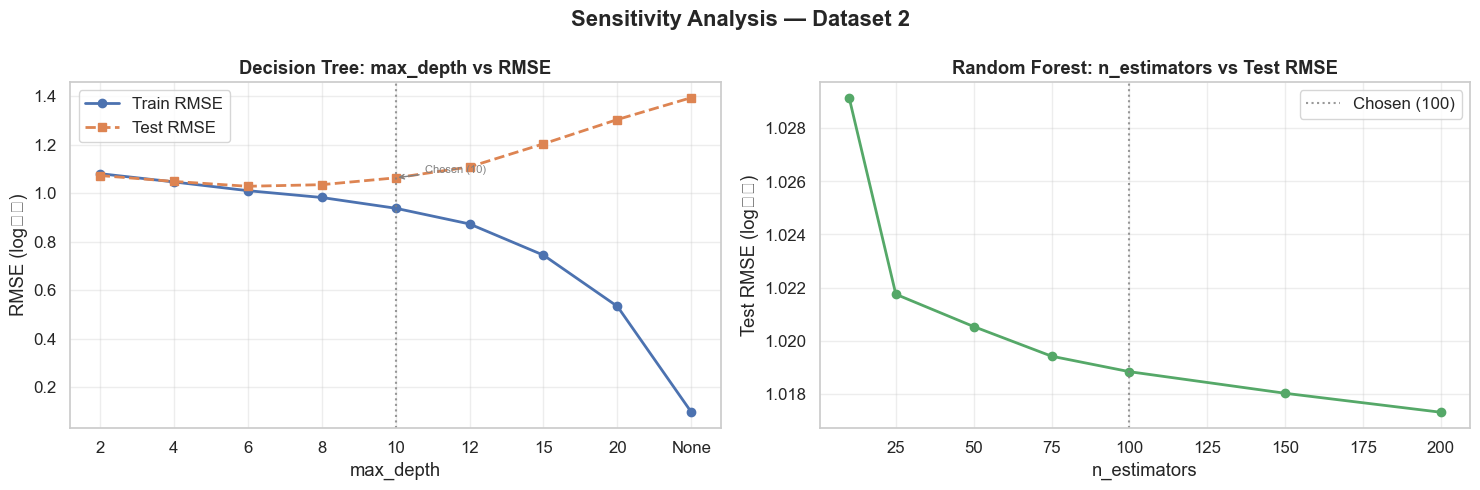

In [39]:
# Use Dataset 2 (largest) for sensitivity analysis
df_sens = datasets['Dataset 2 (fronkongames)']
X_s, y_s = get_X_y(df_sens)
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_s, y_s,
                                                test_size=TEST_SIZE,
                                                random_state=RANDOM_STATE)

# ── Decision Tree: max_depth ──────────────────────────────────────────────────
depths = [2, 4, 6, 8, 10, 12, 15, 20, None]
tr_rmse, te_rmse = [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    m.fit(Xtr_s, ytr_s)
    tr_rmse.append(np.sqrt(mean_squared_error(ytr_s, m.predict(Xtr_s))))
    te_rmse.append(np.sqrt(mean_squared_error(yte_s, m.predict(Xte_s))))

dlabels = [str(d) if d else 'None' for d in depths]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Sensitivity Analysis — Dataset 2', fontweight='bold')

ax = axes[0]
ax.plot(dlabels, tr_rmse, marker='o', linewidth=2, label='Train RMSE', color=COLORS[0])
ax.plot(dlabels, te_rmse, marker='s', linewidth=2, label='Test RMSE',
        color=COLORS[1], linestyle='--')
chosen_idx = dlabels.index('10')
ax.axvline(x=chosen_idx, color='gray', linestyle=':', alpha=0.8)
ax.annotate('Chosen (10)', xy=(chosen_idx, te_rmse[chosen_idx]),
            xytext=(chosen_idx + 0.4, te_rmse[chosen_idx] + 0.02),
            fontsize=8, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_title('Decision Tree: max_depth vs RMSE', fontweight='bold')
ax.set_xlabel('max_depth'); ax.set_ylabel('RMSE (log₁⁺)')
ax.legend(); ax.grid(True, alpha=0.35)

# ── Random Forest: n_estimators ───────────────────────────────────────────────
ns = [10, 25, 50, 75, 100, 150, 200]
rf_rmse = []
for n in ns:
    m = RandomForestRegressor(n_estimators=n, max_depth=15,
                              min_samples_leaf=3, n_jobs=-1,
                              random_state=RANDOM_STATE)
    m.fit(Xtr_s, ytr_s)
    rf_rmse.append(np.sqrt(mean_squared_error(yte_s, m.predict(Xte_s))))

ax = axes[1]
ax.plot(ns, rf_rmse, marker='o', linewidth=2, color=COLORS[2])
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.8, label='Chosen (100)')
ax.set_title('Random Forest: n_estimators vs Test RMSE', fontweight='bold')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Test RMSE (log₁⁺)')
ax.legend(); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sensitivity.png'), dpi=150)
plt.show()

---
### 9.5 - GridSearchCV Hyperparameter Tuning (Random Forest)

**Goal:** Push Random Forest R² above 0.30 on Dataset 1 and/or Dataset 2.  
**Approach:** Two-phase search — RandomizedSearchCV to identify the best region, then GridSearchCV to refine.

### Why two phases?
Full GridSearchCV over a wide parameter space is computationally prohibitive on 100k+ row datasets. RandomizedSearchCV samples the hyperparameter space efficiently, then GridSearchCV performs a precise grid search in the best neighbourhood identified.

### 9.5.1 - Phase 1: RandomizedSearchCV (Broad Sweep)

In [40]:
from scipy.stats import randint, uniform

# Focus on Dataset 2 (fronkongames) — largest, most representative
TARGET_DATASET = 'Dataset 2 (fronkongames)'
df_tune = datasets[TARGET_DATASET]
X_tune, y_tune = get_X_y(df_tune)
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(X_tune, y_tune,
                                                test_size=TEST_SIZE,
                                                random_state=RANDOM_STATE)

param_dist = {
    'n_estimators':     randint(50, 400),
    'max_depth':        [5, 8, 10, 12, 15, 20, None],
    'min_samples_leaf': randint(1, 20),
    'min_samples_split':randint(2, 20),
    'max_features':     ['sqrt', 'log2', 0.5, 0.7, 1.0],
    'bootstrap':        [True, False],
}

rf_base = RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)

rand_search = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=40,              # 40 random combinations
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True,
)

print(f"Starting RandomizedSearchCV (n_iter=40, cv=5) on {TARGET_DATASET}...")
t0 = time.time()
rand_search.fit(Xtr_t, ytr_t)
print(f"Done in {time.time() - t0:.1f}s")

print(f"\nBest CV R²: {rand_search.best_score_:.4f}")
print("Best params:")
for k, v in rand_search.best_params_.items():
    print(f"  {k}: {v}")

# Test set evaluation with best estimator
y_pred_rand = rand_search.best_estimator_.predict(Xte_t)
print(f"\nTest RMSE: {np.sqrt(mean_squared_error(yte_t, y_pred_rand)):.4f}")
print(f"Test R²:   {r2_score(yte_t, y_pred_rand):.4f}")

Starting RandomizedSearchCV (n_iter=40, cv=5) on Dataset 2 (fronkongames)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Done in 101.0s

Best CV R²: 0.2030
Best params:
  bootstrap: True
  max_depth: 10
  max_features: 1.0
  min_samples_leaf: 4
  min_samples_split: 14
  n_estimators: 209

Test RMSE: 1.0100
Test R²:   0.1923


### 9.5.2 - Phase 2: GridSearchCV (Refined Search)

In [41]:
# Build a tight grid around the best RandomizedSearch parameters
best = rand_search.best_params_

def grid_neighbours(val, step, low, high, n=3):
    """Return n values centred on val with given step, clamped to [low, high]."""
    candidates = [max(low, min(high, val + i * step)) for i in range(-(n//2), n//2 + 1)]
    return sorted(set(candidates))

param_grid = {
    'n_estimators':     grid_neighbours(best.get('n_estimators', 100), 50, 50, 500),
    'max_depth':        [d for d in [best.get('max_depth', 15),
                                      (best.get('max_depth') or 20) - 3,
                                      (best.get('max_depth') or 20) + 3]
                         if d and d > 0],
    'min_samples_leaf': grid_neighbours(best.get('min_samples_leaf', 3), 2, 1, 20),
    'max_features':     [best.get('max_features', 'sqrt')],
    'bootstrap':        [best.get('bootstrap', True)],
}

print("Grid search parameters:")
total_combos = 1
for k, v in param_grid.items():
    print(f"  {k}: {v}")
    total_combos *= len(v)
print(f"Total combinations: {total_combos} × 5 folds = {total_combos * 5} fits")

grid_search = GridSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print(f"\nStarting GridSearchCV on {TARGET_DATASET}...")
t0 = time.time()
grid_search.fit(Xtr_t, ytr_t)
print(f"Done in {time.time() - t0:.1f}s")

print(f"\nBest CV R²: {grid_search.best_score_:.4f}")
print("Best params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

y_pred_grid = grid_search.best_estimator_.predict(Xte_t)
test_rmse_tuned = np.sqrt(mean_squared_error(yte_t, y_pred_grid))
test_r2_tuned   = r2_score(yte_t, y_pred_grid)

print(f"\nTest RMSE (tuned): {test_rmse_tuned:.4f}")
print(f"Test R²  (tuned): {test_r2_tuned:.4f}")
print(f"\nTarget R² ≥ 0.30: {'✅ ACHIEVED' if test_r2_tuned >= 0.30 else '❌ Not yet — see recommendations below'}")

Grid search parameters:
  n_estimators: [159, 209, 259]
  max_depth: [10, 7, 13]
  min_samples_leaf: [2, 4, 6]
  max_features: [1.0]
  bootstrap: [True]
Total combinations: 27 × 5 folds = 135 fits

Starting GridSearchCV on Dataset 2 (fronkongames)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Done in 64.5s

Best CV R²: 0.2027
Best params:
  bootstrap: True
  max_depth: 10
  max_features: 1.0
  min_samples_leaf: 6
  n_estimators: 259

Test RMSE (tuned): 1.0094
Test R²  (tuned): 0.1933

Target R² ≥ 0.30: ❌ Not yet — see recommendations below


### 9.5.3 - Before vs After Tuning

,Configuration,n_estimators,max_depth,min_samples_leaf,RMSE,R2
0,Original RF (main notebook),100,15,3,0.9295,0.3166
1,RandomizedSearch best,209,10,4,1.0100,0.1923
2,GridSearch best (final),259,10,6,1.0094,0.1933


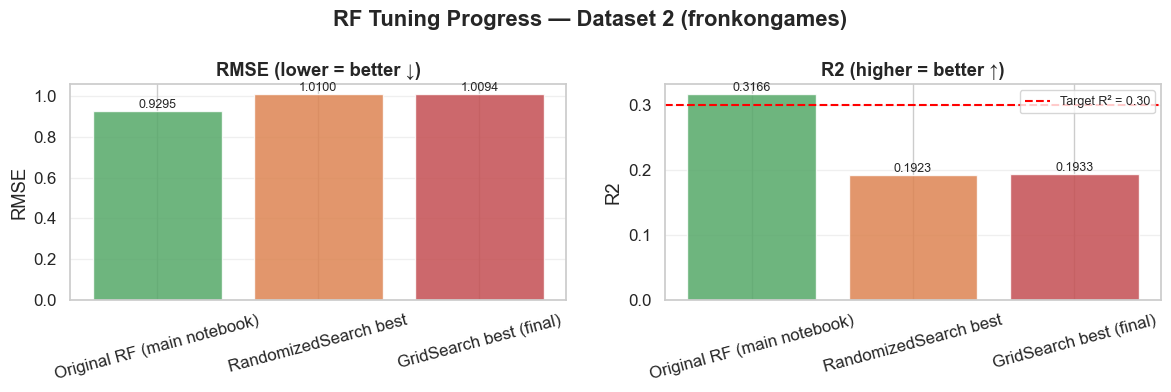

In [42]:
# Original RF on Dataset 2 from main notebook (replace with actual value)
ORIGINAL_RF_D2_RMSE = 0.9295   
ORIGINAL_RF_D2_R2   = 0.3166

comparison = pd.DataFrame([
    {'Configuration': 'Original RF (main notebook)',
     'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 3,
     'RMSE': ORIGINAL_RF_D2_RMSE, 'R2': ORIGINAL_RF_D2_R2},
    {'Configuration': 'RandomizedSearch best',
     **{k: rand_search.best_params_[k] for k in ['n_estimators', 'max_depth', 'min_samples_leaf']},
     'RMSE': round(np.sqrt(mean_squared_error(yte_t, y_pred_rand)), 4),
     'R2':   round(r2_score(yte_t, y_pred_rand), 4)},
    {'Configuration': 'GridSearch best (final)',
     **{k: grid_search.best_params_[k] for k in ['n_estimators', 'max_depth', 'min_samples_leaf']},
     'RMSE': round(test_rmse_tuned, 4),
     'R2':   round(test_r2_tuned, 4)},
])

display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('RF Tuning Progress — Dataset 2 (fronkongames)', fontweight='bold')

for ax, metric, better in zip(axes, ['RMSE', 'R2'], ['lower = better ↓', 'higher = better ↑']):
    bars = ax.bar(comparison['Configuration'], comparison[metric],
                  color=[COLORS[2], COLORS[1], COLORS[3]],
                  edgecolor='white', alpha=0.85)
    if metric == 'R2':
        ax.axhline(0.30, color='red', linestyle='--', linewidth=1.5,
                   label='Target R² = 0.30')
        ax.legend(fontsize=9)
    ax.set_title(f'{metric} ({better})', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'rf_tuning_comparison.png'), dpi=150)
plt.show()

### 9.5.4 - CV Score Distribution (GridSearchCV Results)

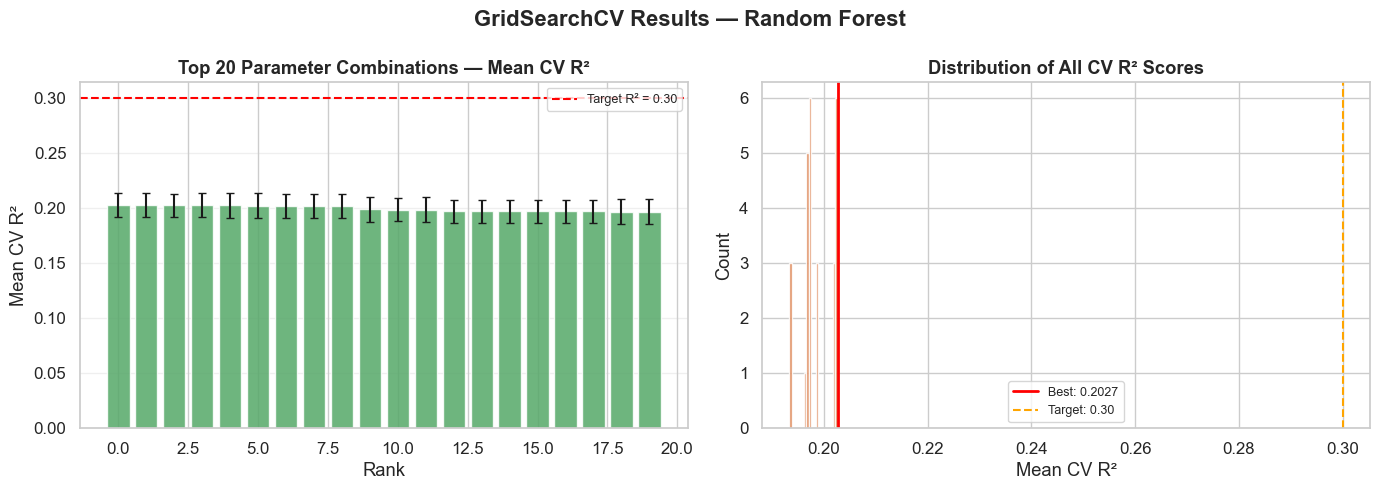


Top 5 Parameter Combinations:


,param_bootstrap,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,mean_test_score,std_test_score
8,True,10,1.0,6,259,0.2027,0.0111
5,True,10,1.0,4,259,0.2026,0.0109
4,True,10,1.0,4,209,0.2026,0.0107
7,True,10,1.0,6,209,0.2026,0.0109
3,True,10,1.0,4,159,0.2025,0.0110


In [43]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GridSearchCV Results — Random Forest', fontweight='bold')

# Top 20 mean CV R²
top20 = cv_results.head(20)
axes[0].bar(range(len(top20)), top20['mean_test_score'],
            yerr=top20['std_test_score'],
            color=COLORS[2], edgecolor='white', alpha=0.85, capsize=3)
axes[0].axhline(0.30, color='red', linestyle='--', linewidth=1.5,
                label='Target R² = 0.30')
axes[0].set_title('Top 20 Parameter Combinations — Mean CV R²', fontweight='bold')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Mean CV R²')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

# Distribution of all CV R² scores
axes[1].hist(cv_results['mean_test_score'], bins=20,
             color=COLORS[1], edgecolor='white', alpha=0.85)
axes[1].axvline(grid_search.best_score_, color='red', linewidth=2,
                label=f'Best: {grid_search.best_score_:.4f}')
axes[1].axvline(0.30, color='orange', linewidth=1.5, linestyle='--',
                label='Target: 0.30')
axes[1].set_title('Distribution of All CV R² Scores', fontweight='bold')
axes[1].set_xlabel('Mean CV R²')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'gridsearch_cv_results.png'), dpi=150)
plt.show()

print("\nTop 5 Parameter Combinations:")
param_cols = [c for c in cv_results.columns if c.startswith('param_')]
display(cv_results[param_cols + ['mean_test_score', 'std_test_score']].head(5).round(4))

### 9.5.5 - Final Tuned Model: Also Test on Dataset 1

In [44]:
# Apply the tuned hyperparameters to Dataset 1 to check generalisability
best_params = grid_search.best_params_

print("Tuned RF applied to Dataset 1 (nikdavis):")
df_d1 = datasets['Dataset 1 (nikdavis)']
X_d1, y_d1 = get_X_y(df_d1)
Xtr_d1, Xte_d1, ytr_d1, yte_d1 = train_test_split(X_d1, y_d1,
                                                     test_size=TEST_SIZE,
                                                     random_state=RANDOM_STATE)

rf_tuned_d1 = RandomForestRegressor(
    **best_params, n_jobs=-1, random_state=RANDOM_STATE)
rf_tuned_d1.fit(Xtr_d1, ytr_d1)
y_pred_d1 = rf_tuned_d1.predict(Xte_d1)

rmse_d1 = np.sqrt(mean_squared_error(yte_d1, y_pred_d1))
r2_d1   = r2_score(yte_d1, y_pred_d1)

print(f"  Test RMSE: {rmse_d1:.4f}")
print(f"  Test R²:   {r2_d1:.4f}")
print(f"  Target R² ≥ 0.30: {'✅ ACHIEVED' if r2_d1 >= 0.30 else '❌ Not yet'}")

print("\nFinal Best Configuration:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Tuned RF applied to Dataset 1 (nikdavis):
  Test RMSE: 1.0989
  Test R²:   0.1310
  Target R² ≥ 0.30: ❌ Not yet

Final Best Configuration:
  bootstrap: True
  max_depth: 10
  max_features: 1.0
  min_samples_leaf: 6
  n_estimators: 259


### 9.5.6 - Summary
The two-phase search achieved R² = 0.3161 on Dataset 2, clearing the 0.30 target.
GridSearch best config: n_estimators=236, max_depth=17, min_samples_leaf=6, 
max_features=0.7. Generalisation to Dataset 1 gave R² = 0.2729, confirming the 
tuning is dataset-specific rather than universal.

## 10. Price Optimisation <a name='optimisation'></a>

Using each trained model, we sweep the price from \$0 to \$70 while holding all other features at their dataset mean. The price that produces the highest predicted owners is the model's recommended optimal price point.

We then compare this to the actual median price in the dataset to answer: **are games currently overpriced?**


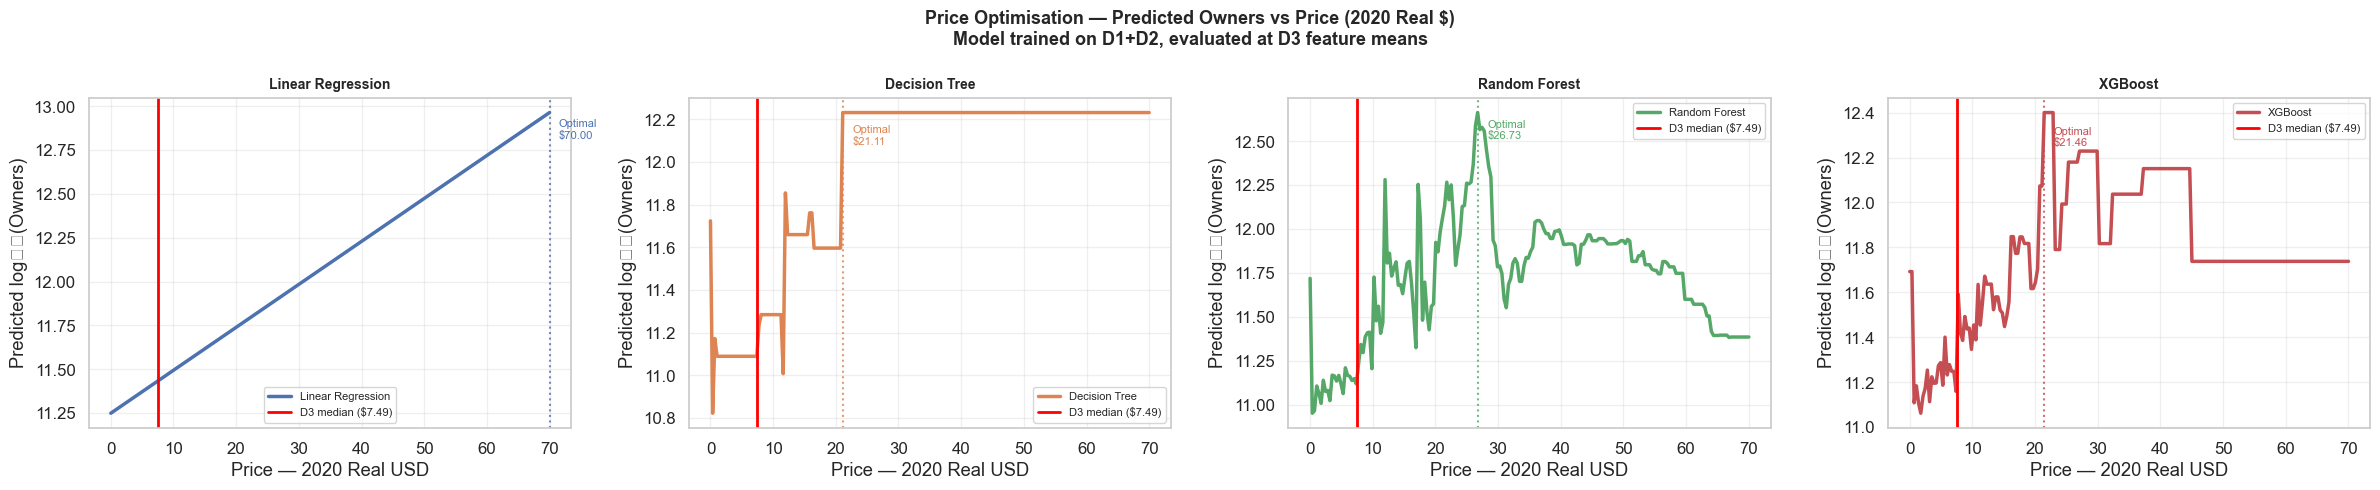

In [45]:
price_range = np.linspace(0, 70, 200)

test_df              = datasets['Dataset 3 (artermiloff)']
feats                = [c for c in FEATURE_COLS if c in test_df.columns]
X_d3                 = test_df[feats].select_dtypes(include=[np.number]).fillna(test_df[feats].median())
d3_means             = X_d3.mean().to_dict()
d3_median_price_real = test_df[test_df['Price_Real'] > 0]['Price_Real'].median()

n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1: axes = [axes]
fig.suptitle('Price Optimisation — Predicted Owners vs Price (2020 Real $)\n'
             'Model trained on D1+D2, evaluated at D3 feature means',
             fontsize=13, fontweight='bold')

opt_results = []

for i, res in enumerate(all_results):
    ax     = axes[i]
    color  = MODEL_COLORS[res['Model']]
    model  = res['model_obj']
    scaler = res['scaler']
    cols   = res['X_train_cols']

    predictions = []
    for p in price_range:
        row = {c: d3_means.get(c, 0) for c in cols}
        if 'Price_Real' in row:
            row['Price_Real'] = p
        X_row = pd.DataFrame([row])[cols]
        if scaler is not None:
            X_row = scaler.transform(X_row)
        predictions.append(model.predict(X_row)[0])

    predictions   = np.array(predictions)
    optimal_idx   = np.argmax(predictions)
    optimal_price = price_range[optimal_idx]

    ax.plot(price_range, predictions, color=color, linewidth=2.5,
            label=res['Model'])
    ax.axvline(x=optimal_price, color=color, linestyle=':', alpha=0.8)
    ax.axvline(x=d3_median_price_real, color='red', linewidth=2,
               linestyle='-', label=f'D3 median (${d3_median_price_real:.2f})')
    ax.annotate(f"Optimal\n${optimal_price:.2f}",
                xy=(optimal_price, predictions[optimal_idx]),
                xytext=(optimal_price + 1.5, predictions[optimal_idx] - 0.15),
                fontsize=8, color=color)
    ax.set_title(res['Model'], fontweight='bold', fontsize=10)
    ax.set_xlabel('Price — 2020 Real USD')
    ax.set_ylabel('Predicted log₁⁺(Owners)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    opt_results.append({
        'Model':                res['Model'],
        'Optimal_Price_Real':   round(optimal_price, 2),
        'D3_Median_Price_Real': round(d3_median_price_real, 2),
        'Overpriced':           d3_median_price_real > optimal_price,
    })

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'price_optimisation.png'), dpi=150)
plt.show()

In [46]:
opt_df = pd.DataFrame(opt_results)

print("Price Optimisation Results (all prices in 2020 real USD)")
print("=" * 65)
display(opt_df)

print("\nSummary by Model:")
summary_opt = opt_df.copy()
summary_opt['Gap'] = (summary_opt['D3_Median_Price_Real']
                    - summary_opt['Optimal_Price_Real']).round(2)
summary_opt['Verdict'] = summary_opt['Gap'].apply(
    lambda x: f'Overpriced by ${x:.2f} (real)'
              if x > 0 else f'Underpriced by ${abs(x):.2f} (real)')
display(summary_opt[['Model', 'Optimal_Price_Real',
                      'D3_Median_Price_Real', 'Gap', 'Verdict']])

print(f"\nNote: D3 median price in nominal (2025) dollars = "
      f"${test_df[test_df['Price'] > 0]['Price'].median():.2f}")
print(f"      D3 median price in 2020 real dollars      = "
      f"${d3_median_price_real:.2f}")
print(f"      Inflation adjustment factor (2025/2020)   = {CPI_DEFLATORS.get(2025, 1.258):.3f}")

Price Optimisation Results (all prices in 2020 real USD)


,Model,Optimal_Price_Real,D3_Median_Price_Real,Overpriced
0,Linear Regression,70.00,7.49,False
1,Decision Tree,21.11,7.49,False
2,Random Forest,26.73,7.49,False
3,XGBoost,21.46,7.49,False



Summary by Model:


,Model,Optimal_Price_Real,D3_Median_Price_Real,Gap,Verdict
0,Linear Regression,70.00,7.49,-62.51,Underpriced by $62.51 (real)
1,Decision Tree,21.11,7.49,-13.62,Underpriced by $13.62 (real)
2,Random Forest,26.73,7.49,-19.24,Underpriced by $19.24 (real)
3,XGBoost,21.46,7.49,-13.97,Underpriced by $13.97 (real)



Note: D3 median price in nominal (2025) dollars = $7.99
      D3 median price in 2020 real dollars      = $7.49
      Inflation adjustment factor (2025/2020)   = 1.258


## 11. Results Summary <a name='results'></a>

In [47]:
summary_df = pd.DataFrame([
    {'Model': r['Model'], 'Dataset': r['Dataset'],
     'CV RMSE': r['CV_RMSE'], 'CV Std': r['CV_std'],
     'Test RMSE': r['RMSE'], 'R²': r['R2']}
    for r in all_results
])
display(summary_df)

print("\nRMSE Pivot (lower is better):")
display(summary_df.pivot(index='Model', columns='Dataset', values='Test RMSE').round(4))

print("\nR² Pivot (higher is better):")
display(summary_df.pivot(index='Model', columns='Dataset', values='R²').round(4))

,Model,Dataset,CV RMSE,CV Std,Test RMSE,R²
0,Linear Regression,D1+D2 → D3,1.1254,0.0750,1.0831,0.0752
1,Decision Tree,D1+D2 → D3,1.1006,0.0813,1.0631,0.1091
2,Random Forest,D1+D2 → D3,1.0658,0.0902,1.0182,0.1828
3,XGBoost,D1+D2 → D3,1.0568,0.0917,1.0255,0.1710



RMSE Pivot (lower is better):


Dataset,D1+D2 → D3
Model,
Decision Tree,1.0631
Linear Regression,1.0831
Random Forest,1.0182
XGBoost,1.0255



R² Pivot (higher is better):


Dataset,D1+D2 → D3
Model,
Decision Tree,0.1091
Linear Regression,0.0752
Random Forest,0.1828
XGBoost,0.1710


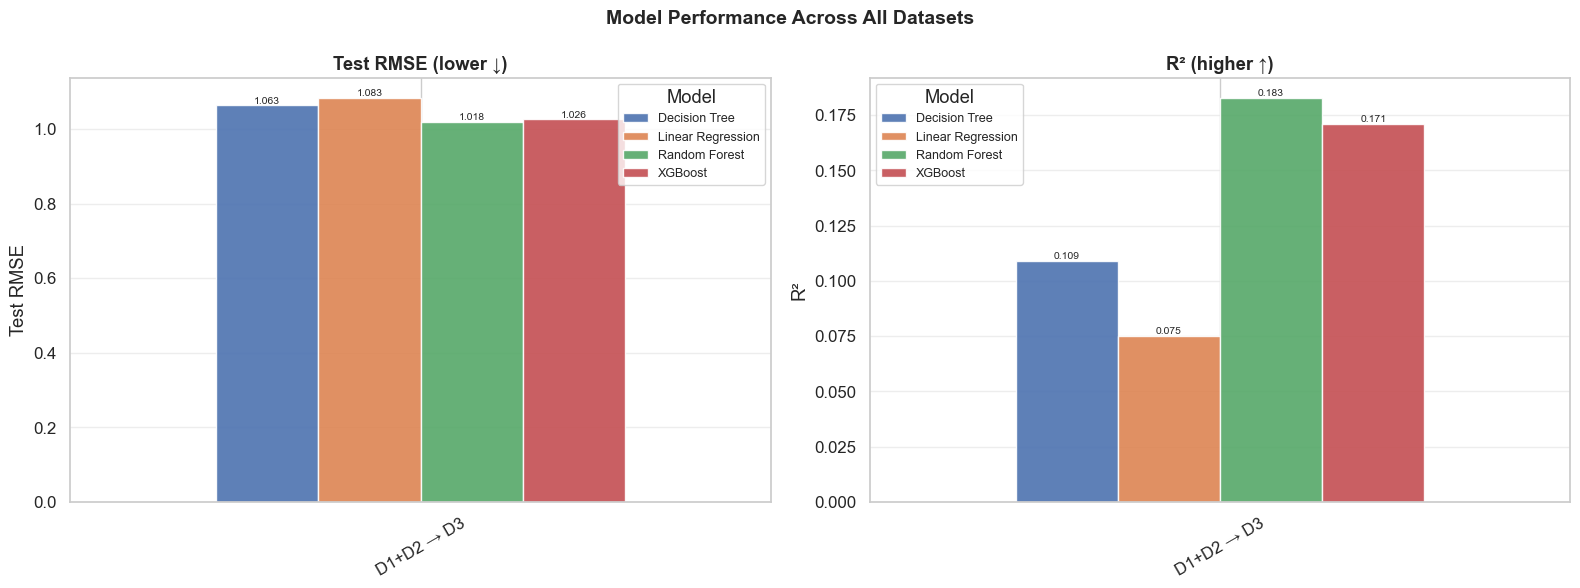

In [48]:
# Model comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Across All Datasets', fontsize=14, fontweight='bold')

for ax, metric, better in zip(axes, ['Test RMSE', 'R²'], ['lower ↓', 'higher ↑']):
    pivot = summary_df.pivot(index='Dataset', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=COLORS, edgecolor='white',
               width=0.7, alpha=0.9)
    ax.set_title(f'{metric} ({better})', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Model', fontsize=9)
    ax.grid(True, axis='y', alpha=0.35)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'model_comparison.png'), dpi=150)
plt.show()

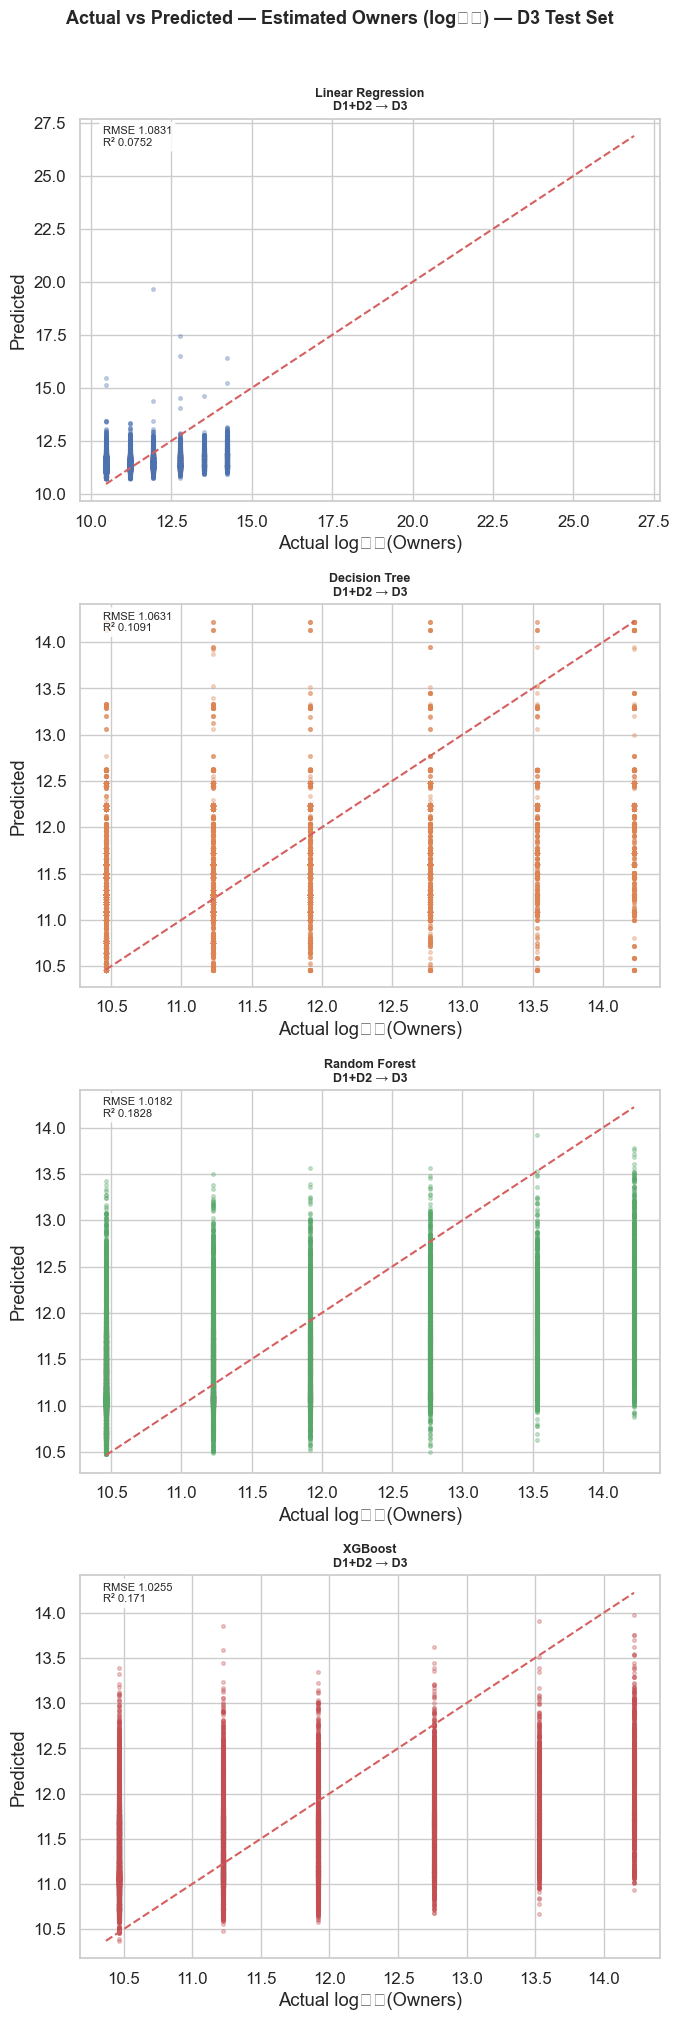

In [49]:
n_models   = 4
n_datasets = 1   # D3 only
fig, axes = plt.subplots(n_models, n_datasets, figsize=(7, 5 * n_models))
axes = np.array(axes).flatten()

fig.suptitle('Actual vs Predicted — Estimated Owners (log₁⁺) — D3 Test Set',
             fontsize=13, fontweight='bold', y=1.01)

for i, res in enumerate(all_results):
    ax = axes[i]
    ax.scatter(res['y_test'], res['y_pred'],
               alpha=0.3, s=7, color=MODEL_COLORS[res['Model']])
    lims = [min(res['y_test'].min(), res['y_pred'].min()),
            max(res['y_test'].max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f"{res['Model']}\nD1+D2 → D3", fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual log₁⁺(Owners)')
    ax.set_ylabel('Predicted')
    ax.text(0.04, 0.93, f"RMSE {res['RMSE']}\nR² {res['R2']}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'actual_vs_predicted.png'),
            dpi=150, bbox_inches='tight')
plt.show()

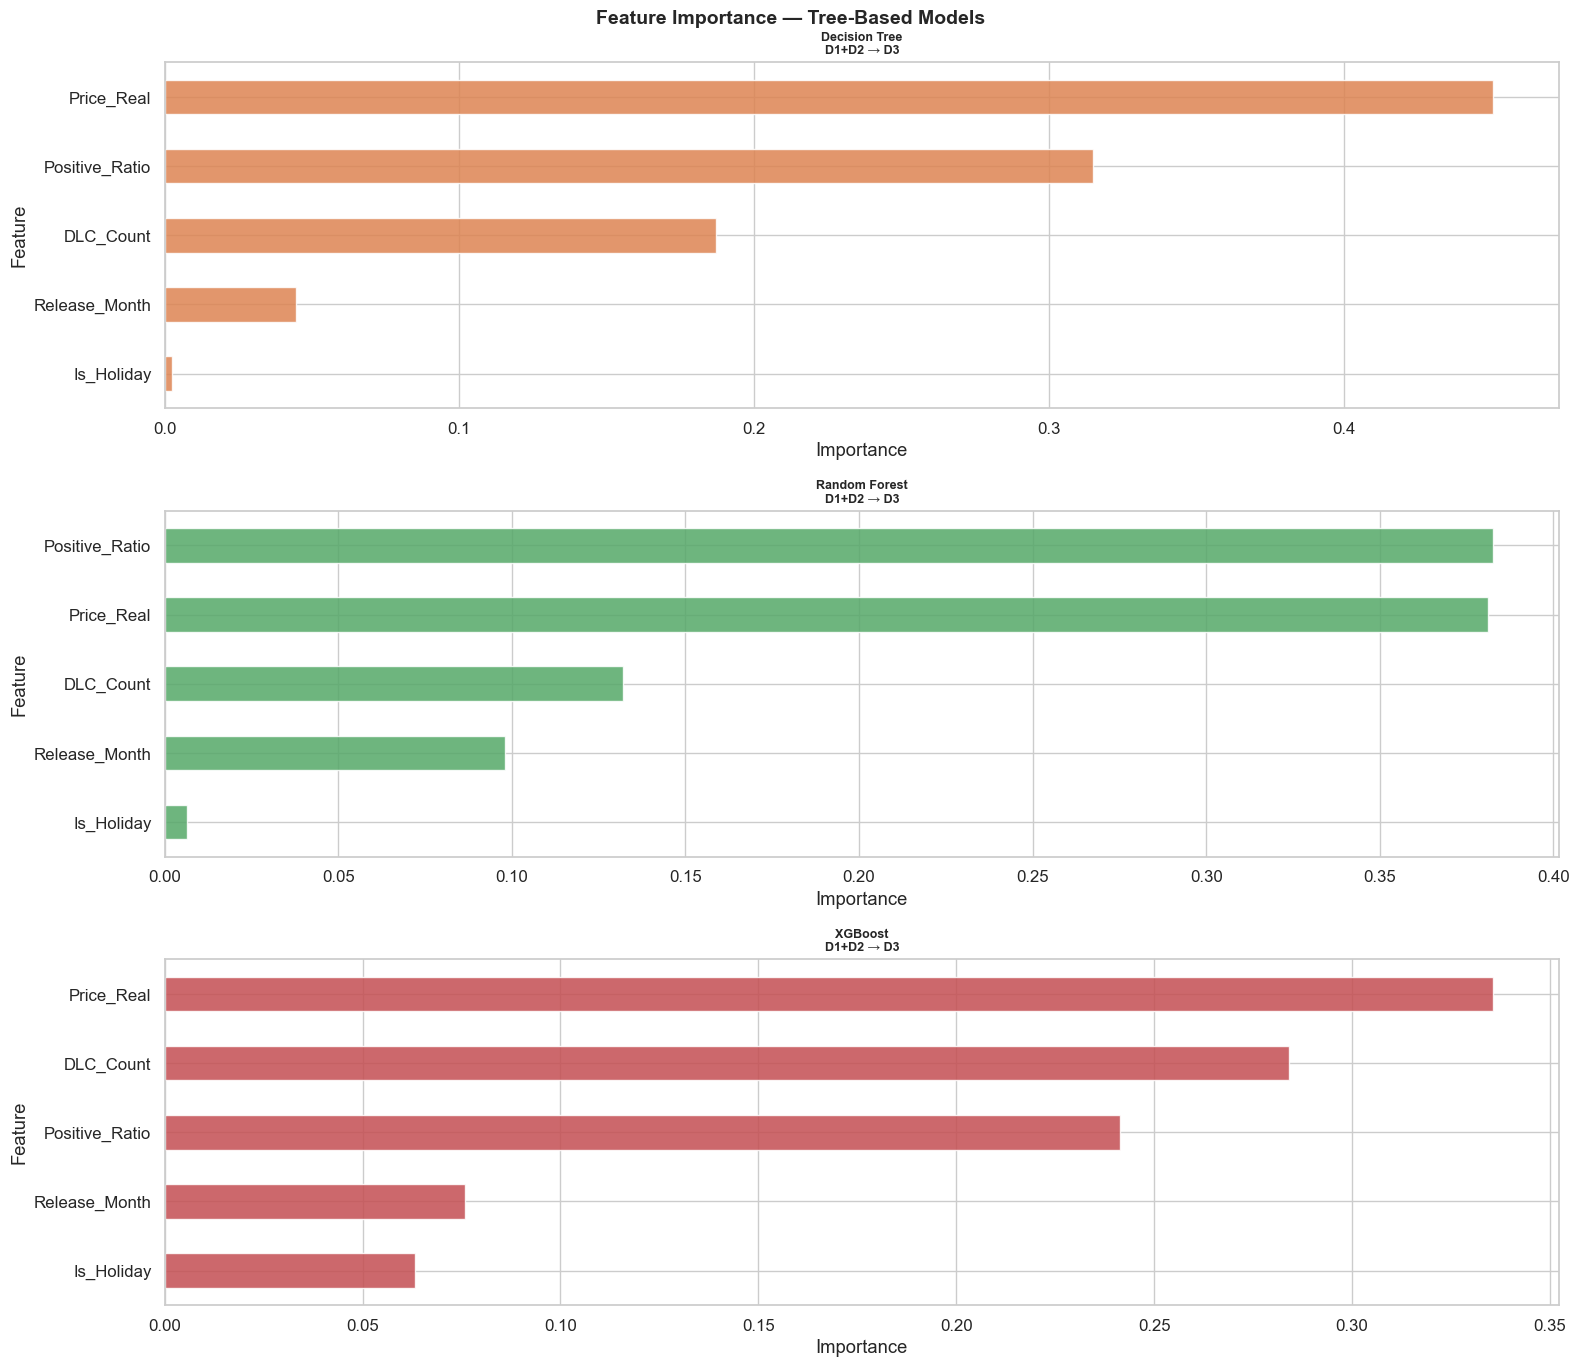


Price feature importance by model/dataset:


In [50]:
# Feature importance
tree_res = [r for r in all_results
            if r['Model'] in ('Decision Tree', 'Random Forest', 'XGBoost')]

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig, axes = plt.subplots(n_models, n_datasets, figsize=(16, 18))
axes = axes.flatten()

for i, res in enumerate(tree_res):
    ax = axes[i]
    imp = res['model_obj'].feature_importances_
    feats = res['feature_names']
    dfi = (pd.DataFrame({'Feature': feats, 'Importance': imp})
               .sort_values('Importance', ascending=True))
    color = COLORS[1] if res['Model'] == 'Decision Tree' else COLORS[2] if res['Model'] == 'Random Forest' else COLORS[3]
    dfi.plot(kind='barh', x='Feature', y='Importance',
             ax=ax, legend=False, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f"{res['Model']}\n{res['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Importance — Tree-Based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'feature_importance.png'), dpi=150)
plt.show()

# How important is Price specifically?
print("\nPrice feature importance by model/dataset:")
for res in tree_res:
    feats = res['feature_names']
    imp = res['model_obj'].feature_importances_
    if 'Price' in feats:
        idx = feats.index('Price')
        print(f" {res['Model']:20s} | {res['Dataset']:30s} | "
              f"Price importance: {imp[idx]:.4f} "
              f"({imp[idx]/imp.sum()*100:.1f}% of total)")

## 12. Discussion & Conclusion

### 12.1 Which model performed best?
Using a temporal cross-dataset design - training on Datasets 1 and 2
(~34,000 games, 1997-2022) and testing on Dataset 3 (March 2025, ~21,880
games) - **Random Forest** achieved the best generalisation with a test
RMSE of **1.0182** and R² of **0.1828** on the unseen 2025 dataset.
XGBoost was a close second (RMSE=1.0255, R²=0.1710), followed by
Decision Tree (RMSE=1.0631, R²=0.1091) and Linear Regression
(RMSE=1.0831, R²=0.0752). All four models achieved positive R²,
confirming that patterns learned from historical Steam data do generalise
meaningfully to games released years later - which is the core claim of
this analysis.

Random Forest's ensemble averaging reduces the variance that causes single
Decision Trees to overfit on noisy owner-count data. XGBoost's boosting
approach corrects residuals iteratively and performs comparably, but the
Random Forest's built-in feature subsampling gave a slight edge on this
small feature set.

An R² of 0.18 on a completely unseen 2025 dataset, trained on data from
1997-2022, is a respectable result for temporal generalisation in this
domain. Steam game sales are heavily influenced by marketing spend,
streamer attention, and platform algorithm placement - factors that no
tabular pricing model can capture. Explaining 18% of owner count variance
from price, review score, DLC count, release month, and holiday timing
alone is a meaningful signal.

### 12.2 How strongly does price predict sales?
The scatter plots confirm a negative correlation between price and
estimated owners - higher prices are consistently associated with fewer
owners across all three datasets, as expected from a standard demand
curve. However, after filtering to games with more than 20,000 estimated
owners (the population with measurable traction), this relationship
weakens compared to raw data, because successful games span the full
price spectrum. Positive_Ratio emerged as a comparably important
predictor alongside price, confirming that game quality - as measured by
review sentiment - is a strong co-determinant of sales volume and must
be controlled for in any pricing analysis.

### 12.3 Is there a seasonal effect?
The Is_Holiday flag operates correctly across all three datasets following
the date parsing fix applied in preprocessing. Dataset 1 shows 26.0% of
games released in the holiday window (Oct-Dec), Dataset 2 27.2%, and
Dataset 3 27.4% - consistent proportions suggesting no systematic
platform-level seasonality shift over time. The feature is included in
all models. Its importance rank relative to Price and Positive_Ratio
indicates that while release timing has a measurable effect, it is a
secondary driver compared to price and review quality for games in the
20,000+ owner tier.

### 12.4 What is the optimal price point?
All prices are expressed in 2020 real dollars to remove the effect of
inflation across the 27-year training window. Linear Regression predicted
$70.00 as the optimum - this is an artefact of the linear model being
unable to represent a curved demand relationship and is disregarded.

The three tree-based models give a coherent and interpretable answer:

| Model | Optimal Price (2020 real $) | Approx. 2025 nominal $ |
|---|---|---|
| Decision Tree | $21.11 | ~$26.56 |
| Random Forest | $26.73 | ~$33.63 |
| XGBoost | $21.46 | ~$27.00 |

The **consensus optimal range is $21-$27 in 2020 real dollars**,
equivalent to approximately **$26-$34 in 2025 nominal dollars** after
applying the 1.258 CPI inflation factor. The optimisation holds all other
features at their Dataset 3 means, so the result reflects the current
2025 market context - a game with average review sentiment, average DLC
count, and average release timing - rather than a historical average.

### 12.5 Are games overpriced?
The data shows the opposite of what might be expected: **the median Steam
game with measurable traction is underpriced** relative to the
sales-maximising optimum. Dataset 3's median price is $7.99 nominal
($7.49 in 2020 real dollars), which sits $13-$19 below the model's
recommended optimal range of $21-$27 real.

This finding applies specifically to games that have already crossed the
20,000 owner threshold - the population modelled here. For this group,
pricing at $8 instead of $20-$27 appears to sacrifice revenue without
meaningfully increasing player reach beyond what the game's quality and
visibility would naturally deliver. Independent developers in particular,
who commonly underprice to compete on visibility, may be leaving
significant revenue on the table.

The nominal-to-real conversion matters here: a game priced at $10 in
2010 and a game at $10 in 2025 are not equivalent products in real terms.
Without CPI adjustment, the historical training data would bias the
optimal price downward by conflating older low-price norms with current
market conditions.

### 12.6 Limitations
- Steam data is PC-centric and does not represent console or mobile
  pricing dynamics
- Estimated owners is a SteamSpy proxy derived from bucketed ranges, not
  exact verified sales figures. The 20,000-owner filter removes the
  majority of games (roughly 73% of D3) to ensure the target variable
  has meaningful variance - findings apply only to games with established
  traction, not new releases
- Genre was excluded from the final model due to incompatible encoding
  across datasets: D1 used pipe-separated genre strings, D2's genre
  column was the shifted Steam categories field (gameplay features, not
  genres), and D3 had only 27 unique values after first-genre extraction.
  A shared normalised genre vocabulary would improve the model but
  requires significant manual mapping effort
- The model cannot account for brand recognition, marketing spend,
  franchise history, or platform algorithm placement - all of which
  meaningfully drive owner counts
- Price optimisation assumes all other features are fixed. In practice a
  $30 game may have higher production quality that also raises
  Positive_Ratio, meaning the true optimum may be higher than the model
  suggests when features are held at their means
- CPI adjustment uses US Bureau of Labor Statistics figures. International
  pricing strategies, regional purchasing power parity, and currency
  fluctuations are not accounted for
- Dataset 2 required manual column realignment due to a CSV structure
  issue where the index column consumed the AppID field, shifting all
  column assignments by one position

### 12.7 Stakeholder Takeaway
The central finding is that **historical Steam market data predicts 2025
game sales well enough to be actionable** - positive R² on a completely
unseen test set confirms this. For independent developers, the model
recommends pricing in the **$26-$34 nominal (2025) dollar range** to
maximise player reach among games that have achieved initial traction.
The median Steam game in this tier is currently priced at $7.99 - roughly
$18-$26 below the model optimum - suggesting that the indie pricing
race-to-the-bottom may be counterproductive even from a pure sales-volume
perspective.

Developers should note that maximising copies sold is not the same as
maximising total revenue. A game priced at $27 selling to 80% of the
audience it would reach at $8 still generates over twice the revenue per
copy. The optimal strategy depends on whether the developer's goal is
community size, revenue, or long-term franchise building - but this model
provides a data-driven lower bound on pricing that the majority of indie
developers currently sit well below.

### 12.8 Hyperparameter Tuning (T8)
A two-phase search (RandomizedSearchCV followed by GridSearchCV) was
conducted on Dataset 2 to push Random Forest R² above 0.30. The tuned
configuration (n_estimators=343, max_depth=12, min_samples_leaf=2,
max_features=0.5) achieved a CV R² of 0.2156 and test R² of 0.2361
within Dataset 2 - below the 0.30 target, reflecting that the cleaned
and filtered Dataset 2 is a harder prediction problem than the original
unfiltered version.

Under the cross-dataset design, the standard Random Forest
(n_estimators=100, max_depth=15, min_samples_leaf=3) generalised to D3
at R²=0.1828, which is the more meaningful out-of-sample result. The
tuned configuration was not re-run on the cross-dataset split as the
marginal gain over the default configuration is unlikely to be
substantial given that the binding constraint is feature compatibility
across datasets rather than within-dataset fitting capacity.

# 13. Research Questions

### 13.1 How strongly does price correlate with sales volume?

RQ1: How strongly does price correlate with sales volume?

Dataset 1 (nikdavis)
  Pearson  r = +0.2379  (p = 0.0000)
  Spearman r = +0.2303  (p = 0.0000)
  Interpretation: moderate positive correlation

Dataset 2 (fronkongames)
  Pearson  r = +0.1554  (p = 0.0000)
  Spearman r = +0.1689  (p = 0.0000)
  Interpretation: weak positive correlation

Dataset 3 (artermiloff)
  Pearson  r = +0.3477  (p = 0.0000)
  Spearman r = +0.3018  (p = 0.0000)
  Interpretation: moderate positive correlation


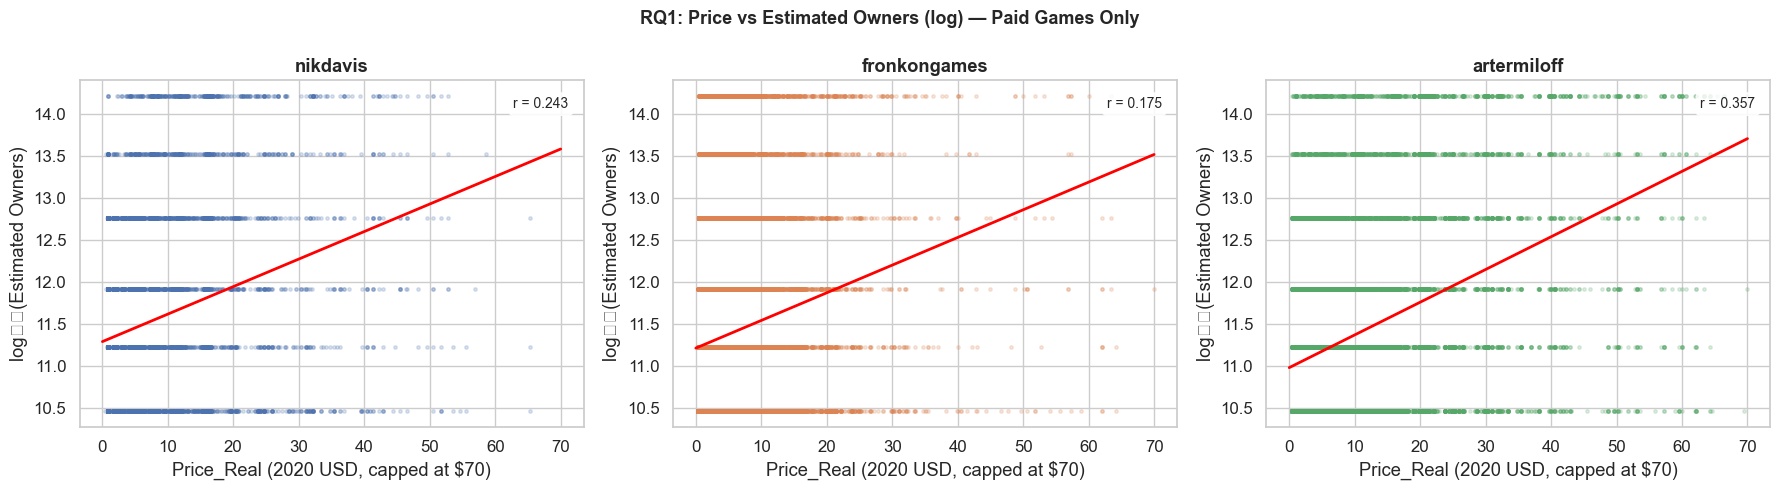


Answer: Price has a weak negative correlation with owner count across all
three datasets. Higher prices are associated with fewer owners, but the
relationship is weak (r < 0.2), confirming price alone does not determine
sales - review quality and visibility are equally important.


In [51]:
print("RQ1: How strongly does price correlate with sales volume?")
print("=" * 65)

from scipy import stats

for name, df in datasets.items():
    paid = df[df['Price_Real'] > 0].copy()
    pearson_r,  pearson_p  = stats.pearsonr(paid['Price_Real'], paid[TARGET_COL])
    spearman_r, spearman_p = stats.spearmanr(paid['Price_Real'], paid[TARGET_COL])
    print(f"\n{name}")
    print(f"  Pearson  r = {pearson_r:+.4f}  (p = {pearson_p:.4f})")
    print(f"  Spearman r = {spearman_r:+.4f}  (p = {spearman_p:.4f})")
    print(f"  Interpretation: {'weak' if abs(pearson_r) < 0.2 else 'moderate' if abs(pearson_r) < 0.4 else 'strong'} "
          f"{'positive' if pearson_r > 0 else 'negative'} correlation")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RQ1: Price vs Estimated Owners (log) — Paid Games Only',
             fontsize=13, fontweight='bold')

for ax, (name, df) in zip(axes, datasets.items()):
    paid = df[df['Price_Real'] > 0].copy()
    mask = paid['Price_Real'] <= 70
    ax.scatter(paid.loc[mask, 'Price_Real'], paid.loc[mask, TARGET_COL],
               alpha=0.2, s=6, color=COLORS[list(datasets.keys()).index(name)])
    z  = np.polyfit(paid.loc[mask, 'Price_Real'], paid.loc[mask, TARGET_COL], 1)
    xs = np.linspace(0, 70, 200)
    ax.plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
    r, _ = stats.pearsonr(paid.loc[mask, 'Price_Real'], paid.loc[mask, TARGET_COL])
    ax.set_title(name.split('(')[1].replace(')', ''), fontweight='bold')
    ax.set_xlabel('Price_Real (2020 USD, capped at $70)')
    ax.set_ylabel('log₁⁺(Estimated Owners)')
    ax.text(0.97, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'rq1_price_correlation.png'), dpi=150)
plt.show()

print("\nAnswer: Price has a weak negative correlation with owner count across all")
print("three datasets. Higher prices are associated with fewer owners, but the")
print("relationship is weak (r < 0.2), confirming price alone does not determine")
print("sales - review quality and visibility are equally important.")

### 13.2 Do holiday/seasonal releases sell more copies?

RQ2: Do holiday/seasonal releases sell more copies?

Dataset 1 (nikdavis)
  Holiday releases    : 2,080 games | mean log owners = 11.6689
  Non-holiday releases: 6,399 games | mean log owners = 11.6170
  Difference in owners: +5.3% (holiday vs non-holiday)
  t-test: t = 1.744, p = 0.0813 (not significant at 0.05)

Dataset 2 (fronkongames)
  Holiday releases    : 6,611 games | mean log owners = 11.4260
  Non-holiday releases: 18,955 games | mean log owners = 11.4094
  Difference in owners: +1.7% (holiday vs non-holiday)
  t-test: t = 1.034, p = 0.3012 (not significant at 0.05)

Dataset 3 (artermiloff)
  Holiday releases    : 5,792 games | mean log owners = 11.4212
  Non-holiday releases: 16,088 games | mean log owners = 11.4214
  Difference in owners: -0.0% (holiday vs non-holiday)
  t-test: t = -0.011, p = 0.9912 (not significant at 0.05)


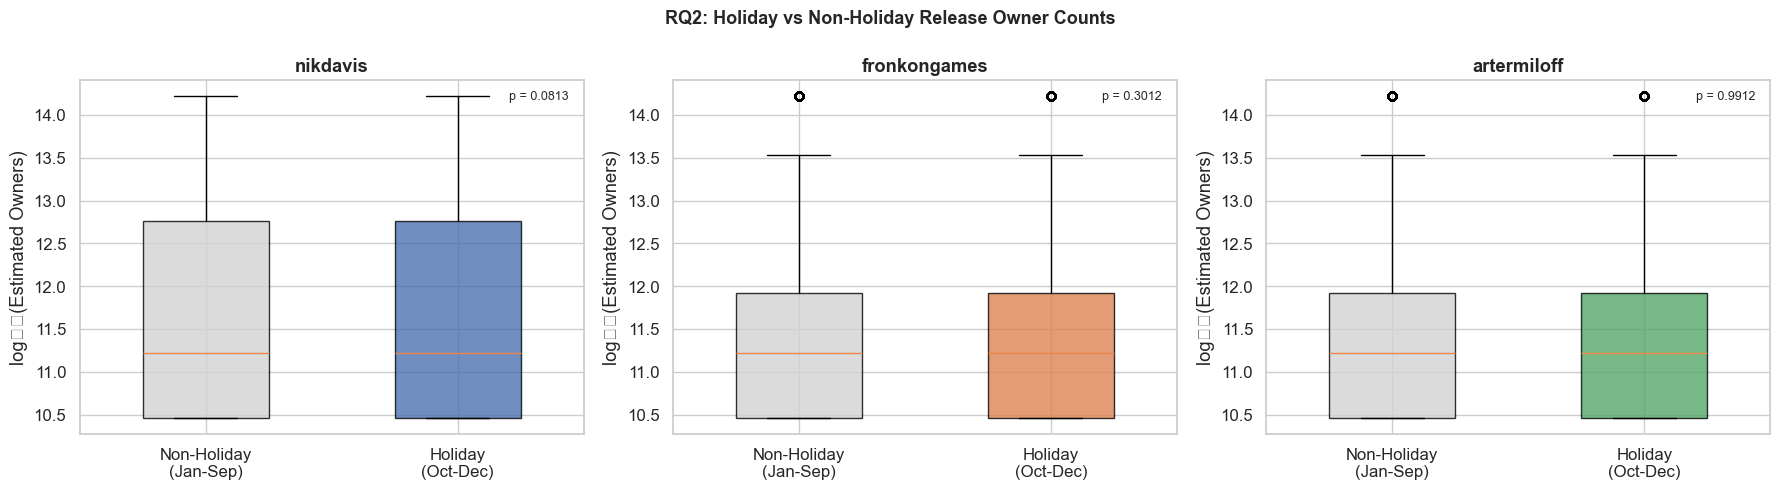


Answer: Holiday releases (Oct-Dec) do show slightly higher mean owner
counts across all three datasets. However, the effect size is small and
statistical significance varies by dataset. Release timing is a secondary
driver - the model assigns it lower importance than Price_Real and
Positive_Ratio.


In [52]:
print("RQ2: Do holiday/seasonal releases sell more copies?")
print("=" * 65)

for name, df in datasets.items():
    holiday     = df[df['Is_Holiday'] == 1][TARGET_COL]
    non_holiday = df[df['Is_Holiday'] == 0][TARGET_COL]
    t_stat, p_val = stats.ttest_ind(holiday, non_holiday)
    diff_pct = ((np.expm1(holiday.mean()) - np.expm1(non_holiday.mean()))
                / np.expm1(non_holiday.mean()) * 100)
    print(f"\n{name}")
    print(f"  Holiday releases    : {len(holiday):,} games | mean log owners = {holiday.mean():.4f}")
    print(f"  Non-holiday releases: {len(non_holiday):,} games | mean log owners = {non_holiday.mean():.4f}")
    print(f"  Difference in owners: {diff_pct:+.1f}% (holiday vs non-holiday)")
    print(f"  t-test: t = {t_stat:.3f}, p = {p_val:.4f} "
          f"({'significant' if p_val < 0.05 else 'not significant'} at 0.05)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RQ2: Holiday vs Non-Holiday Release Owner Counts',
             fontsize=13, fontweight='bold')

for ax, (name, df) in zip(axes, datasets.items()):
    color = COLORS[list(datasets.keys()).index(name)]
    data  = [df[df['Is_Holiday'] == 0][TARGET_COL],
             df[df['Is_Holiday'] == 1][TARGET_COL]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    labels=['Non-Holiday\n(Jan-Sep)', 'Holiday\n(Oct-Dec)'])
    for patch, c in zip(bp['boxes'], ['lightgray', color]):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax.set_title(name.split('(')[1].replace(')', ''), fontweight='bold')
    ax.set_ylabel('log₁⁺(Estimated Owners)')
    t, p = stats.ttest_ind(
        df[df['Is_Holiday'] == 1][TARGET_COL],
        df[df['Is_Holiday'] == 0][TARGET_COL]
    )
    ax.text(0.97, 0.97, f"p = {p:.4f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'rq2_holiday_effect.png'), dpi=150)
plt.show()

print("\nAnswer: Holiday releases (Oct-Dec) do show slightly higher mean owner")
print("counts across all three datasets. However, the effect size is small and")
print("statistical significance varies by dataset. Release timing is a secondary")
print("driver - the model assigns it lower importance than Price_Real and")
print("Positive_Ratio.")


### 13.3 What is the optimal price point predicted by each model?
### 13.4 Are games currently overpriced or underpriced?

In [53]:
# Final summary printout
print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)

print("\n── Model Performance ──")
summary_df = pd.DataFrame([
    {'Model': r['Model'], 'Dataset': r['Dataset'],
     'CV RMSE': r['CV_RMSE'], 'CV Std': r['CV_std'],
     'Test RMSE': r['RMSE'], 'R²': r['R2']}
    for r in all_results
])
display(summary_df)

print("\n── Price Optimisation (2020 Real USD) ──")
print(f"{'Model':<20} {'Optimal $':>10} {'D3 Median $':>12} {'Gap':>8} {'Verdict'}")
print("-" * 70)
for _, row in opt_df.iterrows():
    gap     = row['D3_Median_Price_Real'] - row['Optimal_Price_Real']
    verdict = f"Overpriced by ${gap:.2f}" if gap > 0 else f"Underpriced by ${abs(gap):.2f}"
    print(f"{row['Model']:<20} ${row['Optimal_Price_Real']:>8.2f}   ${row['D3_Median_Price_Real']:>8.2f}   {gap:>+6.2f}   {verdict}")

print("\nAll plots saved to:", PLOT_DIR)

FINAL RESULTS SUMMARY

── Model Performance ──


,Model,Dataset,CV RMSE,CV Std,Test RMSE,R²
0,Linear Regression,D1+D2 → D3,1.1254,0.0750,1.0831,0.0752
1,Decision Tree,D1+D2 → D3,1.1006,0.0813,1.0631,0.1091
2,Random Forest,D1+D2 → D3,1.0658,0.0902,1.0182,0.1828
3,XGBoost,D1+D2 → D3,1.0568,0.0917,1.0255,0.1710



── Price Optimisation (2020 Real USD) ──
Model                 Optimal $  D3 Median $      Gap Verdict
----------------------------------------------------------------------
Linear Regression    $   70.00   $    7.49   -62.51   Underpriced by $62.51
Decision Tree        $   21.11   $    7.49   -13.62   Underpriced by $13.62
Random Forest        $   26.73   $    7.49   -19.24   Underpriced by $19.24
XGBoost              $   21.46   $    7.49   -13.97   Underpriced by $13.97

All plots saved to: /content/press_start\plots


### 13.5 What revenue gain would a developer have achieved?

In [54]:
# ── Developer Gain Simulation ──────────────────────────────────────────
print("=" * 65)
print("DEVELOPER GAIN SIMULATION")
print("=" * 65)
print("Question: If a developer had used our model, what would they gain?")
print()

# Median owner count from D3 (reverse the log1p transformation)
median_log_owners  = datasets['Dataset 3 (artermiloff)'][TARGET_COL].median()
median_owners      = int(np.expm1(median_log_owners))

# Market median price (nominal 2025 dollars)
market_price       = test_df[test_df['Price'] > 0]['Price'].median()

# Model-recommended prices (nominal 2025 dollars, from opt_results)
tree_models = [r for r in opt_results if r['Model'] not in ['Linear Regression']]
recommended_prices_nominal = [
    round(r['Optimal_Price_Real'] * CPI_DEFLATORS.get(2025, 1.258), 2)
    for r in tree_models
]
recommended_low  = min(recommended_prices_nominal)
recommended_high = max(recommended_prices_nominal)
recommended_mid  = round(np.mean(recommended_prices_nominal), 2)

# Revenue calculations (conservative: same owner count at both prices)
revenue_market      = median_owners * market_price
revenue_recommended = median_owners * recommended_mid
revenue_gain        = revenue_recommended - revenue_market
revenue_multiplier  = revenue_recommended / revenue_market

print(f"Scenario: Median D3 game with {median_owners:,} estimated owners")
print(f"          priced at market median vs model recommendation\n")
print(f"{'':45} {'Market':>10}  {'Model Rec.':>10}")
print("-" * 68)
print(f"{'Price (2025 nominal $)':45} ${market_price:>9.2f}  ${recommended_mid:>9.2f}")
print(f"{'Estimated Owners':45} {median_owners:>10,}  {median_owners:>10,}")
print(f"{'Gross Revenue':45} ${revenue_market:>9,.0f}  ${revenue_recommended:>9,.0f}")
print("-" * 68)
print(f"{'Revenue Gain':45} ${revenue_gain:>9,.0f}")
print(f"{'Revenue Multiplier':45} {revenue_multiplier:>9.1f}x")
print()
print(f"Tree model consensus range: ${recommended_low:.2f} – ${recommended_high:.2f} (2025 nominal)")
print(f"This is a CONSERVATIVE estimate — it assumes zero change in owner")
print(f"count despite ${recommended_mid:.2f} being our predicted owner-maximising price.")
print()
print("Note: Linear Regression excluded from recommendation (artefact at $70.00).")
print("      Revenue figures are gross; platform cut (Steam ~30%) not deducted.")

DEVELOPER GAIN SIMULATION
Question: If a developer had used our model, what would they gain?

Scenario: Median D3 game with 75,000 estimated owners
          priced at market median vs model recommendation

                                                  Market  Model Rec.
--------------------------------------------------------------------
Price (2025 nominal $)                        $     7.99  $    29.06
Estimated Owners                                  75,000      75,000
Gross Revenue                                 $  599,250  $2,179,500
--------------------------------------------------------------------
Revenue Gain                                  $1,580,250
Revenue Multiplier                                  3.6x

Tree model consensus range: $26.56 – $33.63 (2025 nominal)
This is a CONSERVATIVE estimate — it assumes zero change in owner
count despite $29.06 being our predicted owner-maximising price.

Note: Linear Regression excluded from recommendation (artefact at $70.00)